# 4. Results Review: SHAP $\cup$ FFA Scenario Analysis

**Purpose:** Final workflow notebook for summarizing and reviewing completed model results. This replaces a dashboard notebook as the last analytical review step.

This notebook reads existing artifacts from Steps 6-10 and produces review tables and visualizations for:

1. Final model performance and availability.
2. SHAP global feature importance.
3. FFA / pseudo-causal feature importance.
4. Combined SHAP + FFA scenario interaction artifacts.
5. Patient-level explanation coverage.
6. DTW trajectory generation, artifact availability, and results visualization.
7. Cohort PGx NetworkX previews seeded by top SHAP/FFA consensus drug features.

Run this notebook after `3_model_train_shap_ffa.ipynb`. The DTW section runs on EC2 or any local machine that has the required Step 4 `model_events.parquet` inputs available.

## Setup

Configure paths, cohorts, age bands, and plotting defaults. The notebook uses local artifacts created by the workflow and does not mutate pipeline outputs.

In [14]:
from pathlib import Path
import json
import os
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 140
plt.rcParams["savefig.dpi"] = 180

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "py_helpers").exists():
    PROJECT_ROOT = Path("C:/Projects/cpic_time_to_event_analysis")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from py_helpers.constants import REQUIRED_COHORTS, PROJECT_SLUG, S3_BUCKET, age_band_to_fname
from py_helpers.event_density_utils import DENSITY_BINS, list_trained_density_bins, cohort_aggregate_final_model_has_artifacts

RESULTS_ROOT = PROJECT_ROOT / "10_analysis_results" / "visualizations" / "scenario"
RESULTS_REVIEW_ROOT = PROJECT_ROOT / "10_analysis_results" / "visualizations" / "results_review"
RESULTS_REVIEW_ROOT.mkdir(parents=True, exist_ok=True)
FINAL_MODEL_ROOT = PROJECT_ROOT / "6_final_model" / "outputs"
SHAP_ROOT = PROJECT_ROOT / "7_shap_analysis" / "outputs"
FFA_ROOT = PROJECT_ROOT / "8_ffa_analysis" / "outputs"
DTW_ROOT = PROJECT_ROOT / "9_dtw_analysis" / "outputs"


def save_review_figure(filename: str) -> Path:
    path = RESULTS_REVIEW_ROOT / filename
    plt.savefig(path, bbox_inches="tight", facecolor="white")
    print(f"Saved review figure: {path.relative_to(PROJECT_ROOT)}")
    return path

print(f"Project root: {PROJECT_ROOT}")
print(f"Project slug: {PROJECT_SLUG}")
print(f"S3 bucket: {S3_BUCKET}")
print(f"Cohorts: {REQUIRED_COHORTS}")

Project root: /home/pgx3874/cpic_time_to_event_analysis
Project slug: cpic_time_to_event
S3 bucket: pgxdatalake
Cohorts: {'falls': ['65-74', '75-84'], 'ed': ['65-74', '75-84']}


## Generate DTW Artifacts

Run DTW as part of the Results workflow when the required Step 4 `model_events.parquet` files and per-bin SHAP/FFA Consensus Filter artifacts are available on the current machine. This should run on EC2 during the normal workflow, and can also run locally after model data and consensus artifacts have been synced. DTW uses only consensus drug feature importances matched by cohort, age band, and density bin. If required inputs are missing, the cell skips instead of writing placeholder-only DTW artifacts.

In [ ]:
import subprocess

RUN_DTW_ANALYSIS = True
FORCE_DTW_ANALYSIS = False

from py_helpers.model_data_paths import resolve_model_events_path


def _dtw_input_status() -> pd.DataFrame:
    rows = []
    for cohort, bands in REQUIRED_COHORTS.items():
        for age_band in bands:
            model_events_path = resolve_model_events_path(PROJECT_ROOT, cohort, age_band)
            rows.append(
                {
                    "cohort": cohort,
                    "age_band": age_band,
                    "model_events_path": str(model_events_path or ""),
                    "model_events_exists": bool(model_events_path and model_events_path.exists()),
                }
            )
    return pd.DataFrame(rows)


dtw_input_status = _dtw_input_status()
display(dtw_input_status)

missing_dtw_inputs = dtw_input_status.loc[~dtw_input_status["model_events_exists"]]
dtw_script = PROJECT_ROOT / "9_dtw_analysis" / "run_dtw_analysis.py"

if not RUN_DTW_ANALYSIS:
    print("DTW generation skipped because RUN_DTW_ANALYSIS=False.")
elif not dtw_script.exists():
    raise FileNotFoundError(f"DTW workflow script not found: {dtw_script}")
elif not missing_dtw_inputs.empty:
    print(
        "DTW generation skipped because required Step 4 model_events files are missing on this machine. "
        "Run this cell on EC2 after Step 4/Step 6 data is available, or sync model data locally and rerun."
    )
else:
    cmd = [sys.executable, str(dtw_script)]
    if FORCE_DTW_ANALYSIS:
        cmd.append("--force")
    print("Running DTW workflow:", " ".join(cmd))
    result = subprocess.run(
        cmd,
        cwd=PROJECT_ROOT,
        text=True,
        capture_output=True,
    )
    if result.stdout:
        print(result.stdout[-6000:])
    if result.returncode != 0:
        if result.stderr:
            print(result.stderr[-6000:])
        raise RuntimeError(f"DTW workflow failed with exit code {result.returncode}.")
    if result.stderr:
        print(result.stderr[-6000:])
    print("DTW workflow complete.")

## DTW Results Visualization

Review DTW trajectory outputs produced by the workflow. The summary uses generated `chart_data.json`, `sequence_heatmap.json`, and feature-engineering outputs when present, and shows empty-state reasons when DTW could not produce cohort-specific charts.

In [ ]:
def _read_json(path: Path) -> dict:
    if not path.exists():
        return {}
    try:
        return json.loads(path.read_text(encoding="utf-8"))
    except Exception as exc:
        return {"read_error": str(exc)}


def _dtw_features_path(cohort: str, age_band: str):
    abf = age_band_to_fname(age_band)
    feature_dir = DTW_ROOT / "feature_engineering"
    candidates = [
        feature_dir / f"dtw_features_{cohort}_{abf}.parquet",
        feature_dir / f"dtw_features_{cohort}_{abf}.csv",
    ]
    for path in candidates:
        if path.exists():
            return path
    return None


def _dtw_density_feature_paths(cohort: str, age_band: str):
    abf = age_band_to_fname(age_band)
    feature_dir = DTW_ROOT / "feature_engineering"
    return sorted(feature_dir.glob(f"dtw_features_{cohort}_{abf}_density_*.parquet"))


def _dtw_summary_rows() -> list[dict]:
    rows = []
    for cohort, bands in REQUIRED_COHORTS.items():
        for age_band in bands:
            abf = age_band_to_fname(age_band)
            out_dir = DTW_ROOT / cohort / abf
            chart_path = out_dir / "chart_data.json"
            heatmap_path = out_dir / "sequence_heatmap.json"
            plots_dir = out_dir / "plots"
            chart = _read_json(chart_path)
            heatmap = _read_json(heatmap_path)
            metrics = chart.get("metrics", {}) if isinstance(chart.get("metrics"), dict) else {}
            summary = chart.get("summary", {}) if isinstance(chart.get("summary"), dict) else {}
            timing = summary.get("consensus_drug_to_target_days", {}) if isinstance(summary.get("consensus_drug_to_target_days"), dict) else {}
            first_timing = timing.get("first_consensus_drug", {}) if isinstance(timing.get("first_consensus_drug"), dict) else {}
            last_timing = timing.get("last_consensus_drug", {}) if isinstance(timing.get("last_consensus_drug"), dict) else {}
            rows.append(
                {
                    "cohort": cohort,
                    "age_band": age_band,
                    "chart_data": chart_path.exists(),
                    "sequence_heatmap": heatmap_path.exists(),
                    "n_plots": len(list(plots_dir.glob("*.png"))) if plots_dir.exists() else 0,
                    "empty": bool(chart.get("empty") or heatmap.get("empty")),
                    "reason": metrics.get("reason") or chart.get("message") or heatmap.get("message"),
                    "dtw_rows": metrics.get("dtw_rows") or summary.get("total_trajectories") or summary.get("n_rows"),
                    "first_consensus_drug_to_target_n": first_timing.get("n"),
                    "first_consensus_drug_to_target_mean_days": first_timing.get("mean"),
                    "first_consensus_drug_to_target_median_days": first_timing.get("median"),
                    "last_consensus_drug_to_target_n": last_timing.get("n"),
                    "last_consensus_drug_to_target_mean_days": last_timing.get("mean"),
                    "last_consensus_drug_to_target_median_days": last_timing.get("median"),
                    "feature_file": str(_dtw_features_path(cohort, age_band) or ""),
                    "density_feature_files": len(_dtw_density_feature_paths(cohort, age_band)),
                }
            )
    return rows


dtw_summary = pd.DataFrame(_dtw_summary_rows())
display(dtw_summary)
if "review_tables" not in globals():
    review_tables = {}
review_tables["dtw_summary"] = dtw_summary

dtw_cohort_comparison = pd.DataFrame()
comparison_cols = [
    "dtw_rows",
    "first_consensus_drug_to_target_mean_days",
    "first_consensus_drug_to_target_median_days",
    "last_consensus_drug_to_target_mean_days",
    "last_consensus_drug_to_target_median_days",
]
if not dtw_summary.empty and {"cohort", "age_band"}.issubset(dtw_summary.columns):
    available_comparison_cols = [c for c in comparison_cols if c in dtw_summary.columns]
    if available_comparison_cols:
        dtw_cohort_comparison = dtw_summary.pivot_table(
            index="age_band",
            columns="cohort",
            values=available_comparison_cols,
            aggfunc="first",
        )
        dtw_cohort_comparison.columns = [f"{metric}_{cohort}" for metric, cohort in dtw_cohort_comparison.columns]
        dtw_cohort_comparison = dtw_cohort_comparison.reset_index()
        display(dtw_cohort_comparison)
review_tables["dtw_cohort_comparison"] = dtw_cohort_comparison

if dtw_summary.empty or not dtw_summary[["chart_data", "sequence_heatmap"]].any(axis=None):
    print("No DTW result artifacts found yet. Run the DTW generation cell above on EC2 or a local machine with model data.")
else:
    plot_df = dtw_summary.copy()
    plot_df["panel"] = plot_df["cohort"] + " / " + plot_df["age_band"]
    plot_df["dtw_rows"] = pd.to_numeric(plot_df["dtw_rows"], errors="coerce").fillna(0)
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    sns.barplot(data=plot_df, x="panel", y="dtw_rows", hue="empty", ax=axes[0])
    axes[0].set_title("DTW Rows by Cohort / Age Band")
    axes[0].set_xlabel("Cohort / age band")
    axes[0].set_ylabel("DTW rows")
    axes[0].tick_params(axis="x", rotation=35)
    axes[0].legend(title="Empty state")

    artifact_counts = plot_df.melt(
        id_vars=["panel"],
        value_vars=["chart_data", "sequence_heatmap"],
        var_name="artifact",
        value_name="available",
    )
    artifact_counts["available"] = artifact_counts["available"].astype(int)
    sns.barplot(data=artifact_counts, x="panel", y="available", hue="artifact", ax=axes[1])
    axes[1].set_title("DTW Review Artifact Availability")
    axes[1].set_xlabel("Cohort / age band")
    axes[1].set_ylabel("Available artifact")
    axes[1].set_ylim(0, 1.05)
    axes[1].tick_params(axis="x", rotation=35)
    plt.tight_layout()
    save_review_figure("dtw_results_summary.png")
    plt.show()

## DTW Artifact Visuals from JSON

These visuals read the DTW JSON artifacts produced by `9_dtw_analysis/create_dtw_visuals.py`, including cohort-level and density-bin `chart_data.json` plus `sequence_heatmap.json`. They are intended to make the research-question answers inspectable directly from the same artifacts that are synced to S3.

In [ ]:
try:
    import plotly.express as px
    PLOTLY_AVAILABLE = True
except ImportError:
    PLOTLY_AVAILABLE = False
    print("Plotly is not installed in this kernel. Install plotly or run this cell in the EC2 environment if available.")


def save_plotly_review_figure(fig, filename: str) -> Path:
    path = RESULTS_REVIEW_ROOT / filename
    fig.write_html(path, include_plotlyjs="cdn")
    print(f"Saved interactive review figure: {path.relative_to(PROJECT_ROOT)}")
    return path


def _dtw_json_paths(cohort: str, age_band: str):
    abf = age_band_to_fname(age_band)
    base = DTW_ROOT / cohort / abf
    yield None, base / "chart_data.json", base / "sequence_heatmap.json"
    for bin_name in DENSITY_BINS:
        bin_base = base / "density" / bin_name
        yield bin_name, bin_base / "chart_data.json", bin_base / "sequence_heatmap.json"


def _load_dtw_json_records() -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    summary_rows = []
    trajectory_rows = []
    heatmap_rows = []

    for cohort, bands in REQUIRED_COHORTS.items():
        for age_band in bands:
            for bin_name, chart_path, heatmap_path in _dtw_json_paths(cohort, age_band):
                chart = _read_json(chart_path)
                heatmap = _read_json(heatmap_path)
                panel = f"{cohort} / {age_band}" + (f" / {bin_name}" if bin_name else " / all")
                summary = chart.get("summary", {}) if isinstance(chart.get("summary"), dict) else {}
                timing = summary.get("consensus_drug_to_target_days", {}) if isinstance(summary.get("consensus_drug_to_target_days"), dict) else {}
                first_timing = timing.get("first_consensus_drug", {}) if isinstance(timing.get("first_consensus_drug"), dict) else {}
                last_timing = timing.get("last_consensus_drug", {}) if isinstance(timing.get("last_consensus_drug"), dict) else {}
                metrics = chart.get("metrics", {}) if isinstance(chart.get("metrics"), dict) else {}

                summary_rows.append(
                    {
                        "cohort": cohort,
                        "age_band": age_band,
                        "density_bin": bin_name or "all",
                        "panel": panel,
                        "chart_data_exists": chart_path.exists(),
                        "sequence_heatmap_exists": heatmap_path.exists(),
                        "empty": bool(chart.get("empty") or heatmap.get("empty")),
                        "reason": metrics.get("reason") or chart.get("message") or heatmap.get("message"),
                        "dtw_rows": metrics.get("dtw_rows") or summary.get("total_trajectories"),
                        "first_consensus_drug_to_target_n": first_timing.get("n"),
                        "first_consensus_drug_to_target_median_days": first_timing.get("median"),
                        "first_consensus_drug_to_target_mean_days": first_timing.get("mean"),
                        "last_consensus_drug_to_target_n": last_timing.get("n"),
                        "last_consensus_drug_to_target_median_days": last_timing.get("median"),
                        "last_consensus_drug_to_target_mean_days": last_timing.get("mean"),
                    }
                )

                high_risk = chart.get("high_risk_trajectories", {}) if isinstance(chart.get("high_risk_trajectories"), dict) else {}
                xs = high_risk.get("x", []) or []
                ys = high_risk.get("y", []) or []
                ns = high_risk.get("n", []) or []
                for idx, label in enumerate(xs):
                    trajectory_rows.append(
                        {
                            "cohort": cohort,
                            "age_band": age_band,
                            "density_bin": bin_name or "all",
                            "panel": panel,
                            "trajectory_group": label,
                            "target_rate": ys[idx] if idx < len(ys) else None,
                            "n": ns[idx] if idx < len(ns) else None,
                        }
                    )

                for code_type in ["drug", "icd", "cpt"]:
                    block = heatmap.get(code_type, {}) if isinstance(heatmap.get(code_type), dict) else {}
                    codes = block.get("codes", []) or []
                    counts = block.get("counts", []) or []
                    if not codes or not counts:
                        continue
                    for i, code in enumerate(codes):
                        raw = counts[i] if i < len(counts) else 0
                        if isinstance(raw, list):
                            total_count = sum(pd.to_numeric(pd.Series(raw), errors="coerce").fillna(0))
                        else:
                            total_count = pd.to_numeric(pd.Series([raw]), errors="coerce").fillna(0).iloc[0]
                        heatmap_rows.append(
                            {
                                "cohort": cohort,
                                "age_band": age_band,
                                "density_bin": bin_name or "all",
                                "panel": panel,
                                "code_type": code_type,
                                "code": code,
                                "total_count": float(total_count),
                            }
                        )

    return pd.DataFrame(summary_rows), pd.DataFrame(trajectory_rows), pd.DataFrame(heatmap_rows)


dtw_json_summary, dtw_json_trajectory_rates, dtw_json_sequence_counts = _load_dtw_json_records()
display(dtw_json_summary)
if "review_tables" not in globals():
    review_tables = {}
review_tables["dtw_json_summary"] = dtw_json_summary
review_tables["dtw_json_trajectory_rates"] = dtw_json_trajectory_rates
review_tables["dtw_json_sequence_counts"] = dtw_json_sequence_counts

if PLOTLY_AVAILABLE and not dtw_json_summary.empty:
    timing_long = dtw_json_summary.melt(
        id_vars=["cohort", "age_band", "density_bin", "panel"],
        value_vars=[
            "first_consensus_drug_to_target_median_days",
            "last_consensus_drug_to_target_median_days",
        ],
        var_name="timing_metric",
        value_name="median_days_to_target",
    ).dropna(subset=["median_days_to_target"])
    if not timing_long.empty:
        fig = px.bar(
            timing_long,
            x="density_bin",
            y="median_days_to_target",
            color="timing_metric",
            facet_row="cohort",
            facet_col="age_band",
            barmode="group",
            category_orders={"density_bin": ["all", *list(DENSITY_BINS)]},
            title="DTW Consensus Drug Timing to Target by Cohort and Density Bin",
            labels={"median_days_to_target": "Median days to target", "density_bin": "Density bin"},
        )
        fig.update_layout(height=650, legend_title_text="Timing metric")
        # Display inline within the notebook, then persist the same interactive figure for S3 review.
        fig.show()
        save_plotly_review_figure(fig, "dtw_consensus_drug_timing.html")

if PLOTLY_AVAILABLE and not dtw_json_trajectory_rates.empty:
    rates = dtw_json_trajectory_rates.dropna(subset=["target_rate"]).copy()
    if not rates.empty:
        fig = px.bar(
            rates,
            x="trajectory_group",
            y="target_rate",
            color="density_bin",
            facet_row="cohort",
            facet_col="age_band",
            hover_data=["n"],
            title="DTW Target Rate by Trajectory Group from chart_data.json",
            labels={"target_rate": "Target rate", "trajectory_group": "Trajectory group"},
        )
        fig.update_xaxes(tickangle=35)
        fig.update_layout(height=700, legend_title_text="Density bin")
        fig.show()
        save_plotly_review_figure(fig, "dtw_trajectory_target_rates.html")

if PLOTLY_AVAILABLE and not dtw_json_sequence_counts.empty:
    seq_counts = dtw_json_sequence_counts.loc[dtw_json_sequence_counts["code_type"] == "drug"].copy()
    if not seq_counts.empty:
        seq_counts = (
            seq_counts.sort_values(["panel", "total_count"], ascending=[True, False])
            .groupby("panel", as_index=False, group_keys=False)
            .head(10)
        )
        fig = px.bar(
            seq_counts,
            x="total_count",
            y="code",
            color="density_bin",
            facet_col="cohort",
            facet_row="age_band",
            orientation="h",
            title="Top Consensus Drug Tokens from DTW sequence_heatmap.json",
            labels={"total_count": "Sequence heatmap count", "code": "Drug token"},
        )
        fig.update_layout(height=800, legend_title_text="Density bin")
        fig.show()
        save_plotly_review_figure(fig, "dtw_sequence_heatmap_top_drugs.html")

## Artifact Inventory

This table answers the first review question: do we have the expected model, SHAP, FFA, combined scenario, and DTW artifacts for each cohort/age band/bin?

In [15]:
def _scenario_dir(cohort, age_band, bin_name=None):
    base = RESULTS_ROOT / cohort / age_band_to_fname(age_band)
    return base / "bin_models" / bin_name if bin_name else base


def _shap_dir(cohort, age_band, bin_name=None):
    base = SHAP_ROOT / cohort / age_band_to_fname(age_band)
    return base / "bin_models" / bin_name if bin_name else base


def _ffa_dir(cohort, age_band, bin_name=None):
    base = FFA_ROOT / cohort / age_band_to_fname(age_band)
    return base / "bin_models" / bin_name if bin_name else base


def _artifact_row(cohort, age_band, bin_name=None):
    abf = age_band_to_fname(age_band)
    scenario_dir = _scenario_dir(cohort, age_band, bin_name)
    shap_dir = _shap_dir(cohort, age_band, bin_name)
    ffa_dir = _ffa_dir(cohort, age_band, bin_name)
    model_base = FINAL_MODEL_ROOT / cohort / abf
    if bin_name:
        model_base = model_base / "bin_models" / bin_name
    return {
        "cohort": cohort,
        "age_band": age_band,
        "bin": bin_name or "aggregate",
        "model_xgb": (model_base / "models" / "xgboost.joblib").exists() or (model_base / "models" / "xgboost_model.ubj").exists(),
        "model_catboost": (model_base / "models" / "catboost.joblib").exists() or (model_base / "models" / "catboost_model.cbm").exists(),
        "metrics": (model_base / f"{cohort}_{abf}_model_metrics_summary.csv").exists(),
        "shap_importance": (shap_dir / f"{cohort}_{abf}_shap_global_importance_xgboost.csv").exists(),
        "shap_sample": (shap_dir / f"{cohort}_{abf}_shap_sample_values_xgboost.parquet").exists(),
        "ffa_importance": (ffa_dir / "xgboost" / "feature_importance_axp.parquet").exists(),
        "ffa_explanations": (ffa_dir / "xgboost" / "axp_explanations.parquet").exists(),
        "combined_dashboard_json": (scenario_dir / "dashboard_data.json").exists(),
        "combined_importance": (scenario_dir / "combined_importance.csv").exists(),
        "patient_explanations": (scenario_dir / "patient_explanations.csv").exists(),
        "dtw_outputs_dir": (DTW_ROOT / cohort / abf).exists(),
        "scenario_dir": str(scenario_dir),
    }

rows = []
for cohort, bands in REQUIRED_COHORTS.items():
    for age_band in bands:
        trained_bins = list_trained_density_bins(PROJECT_ROOT, cohort, age_band)
        if trained_bins:
            for bin_name in trained_bins:
                rows.append(_artifact_row(cohort, age_band, bin_name))
        if cohort_aggregate_final_model_has_artifacts(PROJECT_ROOT, cohort, age_band) or not trained_bins:
            rows.append(_artifact_row(cohort, age_band, None))

artifact_inventory = pd.DataFrame(rows)
display_cols = [
    "cohort", "age_band", "bin", "model_xgb", "model_catboost", "metrics",
    "shap_importance", "shap_sample", "ffa_importance", "ffa_explanations",
    "combined_dashboard_json", "combined_importance", "patient_explanations", "dtw_outputs_dir",
]
display(artifact_inventory[display_cols])

,cohort,age_band,bin,model_xgb,model_catboost,metrics,shap_importance,shap_sample,ffa_importance,ffa_explanations,combined_dashboard_json,combined_importance,patient_explanations,dtw_outputs_dir
0,falls,65-74,low,True,True,True,True,True,True,True,True,True,True,False
1,falls,65-74,medium,True,True,True,True,True,True,True,True,True,True,False
2,falls,65-74,high,True,True,True,True,True,True,True,True,True,True,False
3,falls,65-74,extreme,True,True,True,True,True,True,True,True,True,True,False
4,falls,65-74,aggregate,True,True,True,False,False,False,False,False,False,False,False
5,falls,75-84,low,True,True,True,True,True,True,True,True,True,True,False
6,falls,75-84,medium,True,True,True,True,True,True,True,True,True,True,False
7,falls,75-84,high,True,True,True,True,True,True,True,True,True,True,False
8,falls,75-84,extreme,True,True,True,True,True,True,True,True,True,True,False
9,falls,75-84,aggregate,True,True,True,False,False,False,False,False,False,False,False


Saved review figure: 10_analysis_results/visualizations/results_review/artifact_availability.png


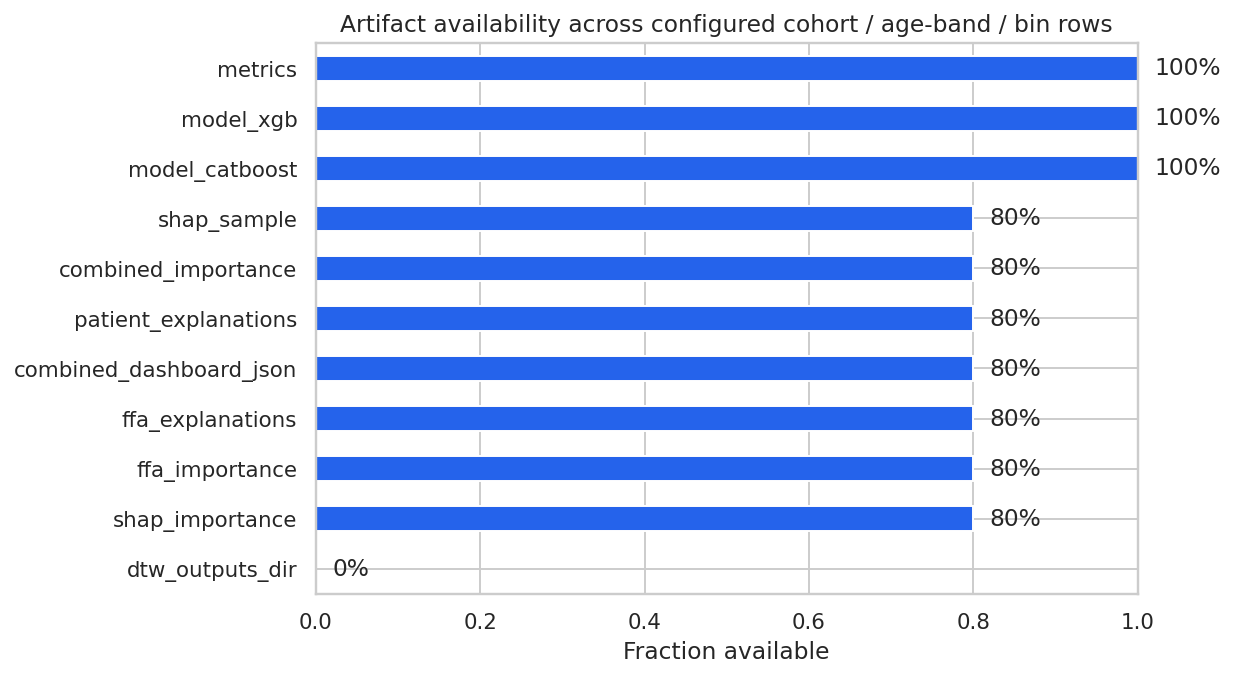

In [16]:
if artifact_inventory.empty:
    print("No Step 6+ artifacts found yet. Run `3_model_train_shap_ffa.ipynb` first.")
else:
    bool_cols = [c for c in display_cols if c not in {"cohort", "age_band", "bin"}]
    coverage = artifact_inventory[bool_cols].mean().sort_values()
    ax = coverage.plot(kind="barh", figsize=(9, 5), color="#2563eb")
    ax.set_xlim(0, 1)
    ax.set_xlabel("Fraction available")
    ax.set_title("Artifact availability across configured cohort / age-band / bin rows")
    for i, v in enumerate(coverage):
        ax.text(v + 0.02, i, f"{v:.0%}", va="center")
    plt.tight_layout()
    save_review_figure("artifact_availability.png")
    plt.show()

## Final Model Performance

Review Step 6 model metrics where available. The notebook searches aggregate and per-bin metric summaries.

In [17]:
def load_model_metrics():
    frames = []
    for _, row in artifact_inventory.iterrows():
        cohort, age_band, bin_name = row["cohort"], row["age_band"], row["bin"]
        abf = age_band_to_fname(age_band)
        base = FINAL_MODEL_ROOT / cohort / abf
        if bin_name != "aggregate":
            base = base / "bin_models" / bin_name
        path = base / f"{cohort}_{abf}_model_metrics_summary.csv"
        if path.exists():
            df = pd.read_csv(path)
            df["cohort"] = cohort
            df["age_band"] = age_band
            df["bin"] = bin_name
            frames.append(df)
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

model_metrics = load_model_metrics()
if model_metrics.empty:
    print("No model metrics found yet.")
else:
    display(model_metrics.head(20))

,model,recall_mean,pr_auc_mean,event_prevalence,pr_auc_random_baseline,pr_auc_lift_over_prevalence,auc_mean,logloss_mean,n_runs,selected,cohort,age_band,bin
0,XGBoost,0.740339,0.808987,0.514589,0.514589,1.572104,0.811686,0.610122,25,False,falls,65-74,low
1,XGBoost_RF,0.743051,0.808641,0.514589,0.514589,1.571432,0.812980,0.538886,25,False,falls,65-74,low
2,CatBoost,0.741017,0.829837,0.514589,0.514589,1.612621,0.822823,0.565167,25,False,falls,65-74,low
3,Ensemble,0.758644,0.835849,0.514589,0.514589,1.624305,0.827569,0.527359,25,True,falls,65-74,low
4,XGBoost,0.670968,0.855936,0.390977,0.390977,2.189222,0.888453,0.434837,25,False,falls,65-74,medium
5,XGBoost_RF,0.571613,0.826071,0.390977,0.390977,2.112836,0.872600,0.480011,25,False,falls,65-74,medium
6,CatBoost,0.659355,0.889996,0.390977,0.390977,2.276336,0.924213,0.401740,25,False,falls,65-74,medium
7,Ensemble,0.689032,0.891589,0.390977,0.390977,2.280411,0.919105,0.370387,25,True,falls,65-74,medium
8,XGBoost,0.392727,0.699442,0.129371,0.129371,5.406499,0.917624,0.249681,25,False,falls,65-74,high
9,XGBoost_RF,0.320000,0.586869,0.129371,0.129371,4.536341,0.868994,0.290629,25,False,falls,65-74,high


,cohort,age_band,bin,model,pr_auc_mean,recall_mean,auc_mean
57,ed,65-74,aggregate,XGBoost_RF,0.506887,0.520000,0.873227
54,ed,65-74,extreme,CatBoost,0.106837,0.000000,0.510029
49,ed,65-74,high,XGBoost_RF,0.075566,0.000000,0.676651
40,ed,65-74,low,XGBoost,0.925475,0.972161,0.896069
45,ed,65-74,medium,XGBoost_RF,0.506887,0.520000,0.873227
77,ed,75-84,aggregate,XGBoost_RF,0.432047,0.276000,0.766444
73,ed,75-84,extreme,XGBoost_RF,0.432047,0.276000,0.766444
69,ed,75-84,high,XGBoost_RF,0.162271,0.000000,0.653319
60,ed,75-84,low,XGBoost,0.960666,0.968800,0.936429
65,ed,75-84,medium,XGBoost_RF,0.432047,0.276000,0.766444


Saved review figure: 10_analysis_results/visualizations/results_review/best_model_performance_heatmap_pr_auc_mean.png


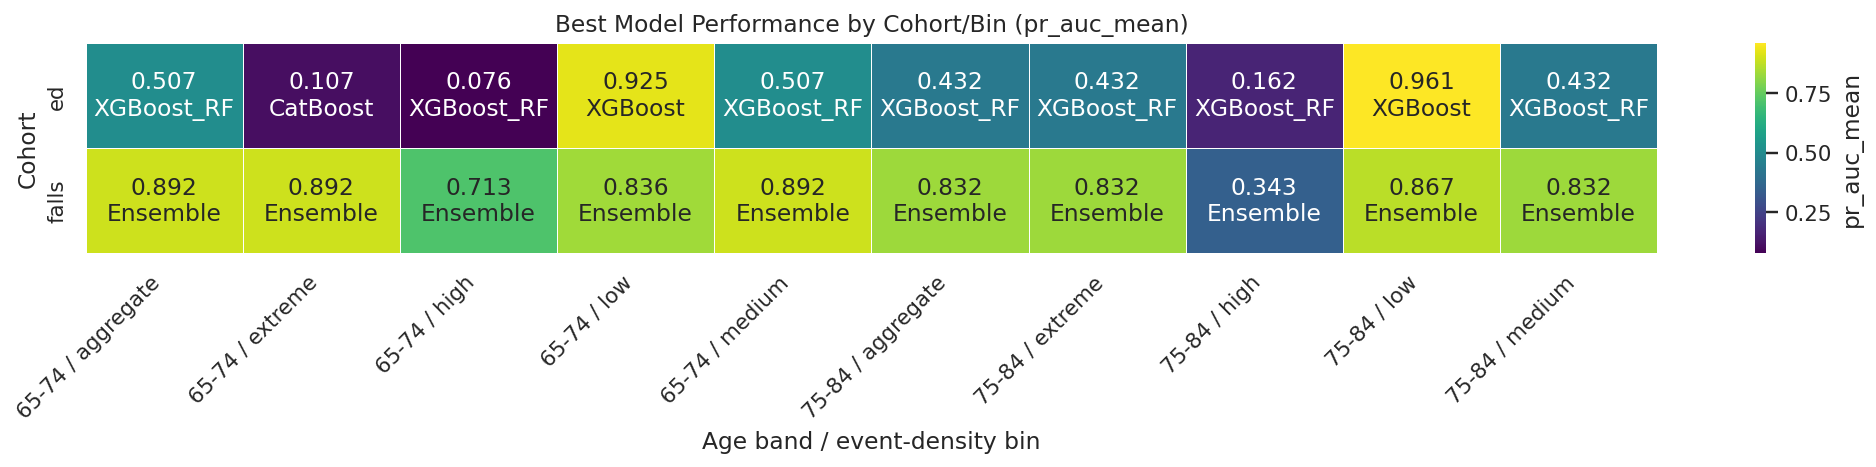

In [18]:
best_model_metrics = pd.DataFrame()

if not model_metrics.empty:
    metric_priority = [
        "pr_auc_mean", "mean_pr_auc", "pr_auc",
        "recall_mean", "f1_mean", "auc_mean", "auroc", "mean_auroc",
    ]
    metric_candidates = [c for c in metric_priority if c in model_metrics.columns]
    lower_is_better = {"logloss", "mean_logloss", "brier", "brier_score"}

    if metric_candidates:
        primary_metric = metric_candidates[0]
        plot_df = model_metrics.copy()
        if "model" not in plot_df.columns:
            plot_df["model"] = plot_df.get("selected_model", "model")
        if "selected" in plot_df.columns:
            selected_mask = plot_df["selected"].astype(str).str.lower().isin(["true", "1", "yes"])
            selected = plot_df.loc[selected_mask].copy()
        else:
            selected = pd.DataFrame()

        if selected.empty:
            ascending = primary_metric in lower_is_better
            selected = (
                plot_df.sort_values(primary_metric, ascending=ascending)
                .groupby(["cohort", "age_band", "bin"], as_index=False)
                .head(1)
                .copy()
            )

        best_model_metrics = selected.copy()
        best_model_metrics["cohort_bin"] = best_model_metrics["cohort"] + " / " + best_model_metrics["age_band"] + " / " + best_model_metrics["bin"].astype(str)
        display_cols = ["cohort", "age_band", "bin", "model"] + metric_candidates
        display(best_model_metrics[[c for c in display_cols if c in best_model_metrics.columns]].sort_values(["cohort", "age_band", "bin"]))

        heatmap_df = best_model_metrics.copy()
        heatmap_df["age_bin"] = heatmap_df["age_band"] + " / " + heatmap_df["bin"].astype(str)
        value_matrix = heatmap_df.pivot_table(
            index="cohort",
            columns="age_bin",
            values=primary_metric,
            aggfunc="first",
        )
        model_matrix = heatmap_df.pivot_table(
            index="cohort",
            columns="age_bin",
            values="model",
            aggfunc="first",
        ).reindex_like(value_matrix)
        annot = value_matrix.copy().astype(object)
        for row_label in value_matrix.index:
            for col_label in value_matrix.columns:
                value = value_matrix.loc[row_label, col_label]
                model_name = model_matrix.loc[row_label, col_label]
                annot.loc[row_label, col_label] = "" if pd.isna(value) else f"{value:.3f}\n{model_name}"

        plt.figure(figsize=(max(10, 1.5 * len(value_matrix.columns)), max(3.5, 0.8 * len(value_matrix))))
        sns.heatmap(
            value_matrix,
            annot=annot,
            fmt="",
            cmap="viridis_r" if primary_metric in lower_is_better else "viridis",
            linewidths=0.5,
            linecolor="white",
            cbar_kws={"label": primary_metric},
        )
        plt.title(f"Best Model Performance by Cohort/Bin ({primary_metric})")
        plt.xlabel("Age band / event-density bin")
        plt.ylabel("Cohort")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        save_review_figure(f"best_model_performance_heatmap_{primary_metric}.png")
        plt.show()
    else:
        print("Metric summary found, but no standard performance metric columns were detected.")

The heatmap uses one row per cohort and one column per age-band/bin combination. Each cell shows the selected model's score and model name, so the visual tracks performance while preserving which model was best for that bin. The `best_model_metrics` table is also saved with the results-review artifacts.

## Top 20 Consensus Feature Importance

This section reviews the interaction/scenario artifacts generated by `10_analysis_results/data_preparation/combine_shap_ffa_results.py`. The first plot shows the top 20 consensus features per cohort, age band, and bin using the combined SHAP + FFA consensus importance score.

In [19]:
def _parse_feature_list(value):
    import ast

    if isinstance(value, (list, tuple, set)):
        return [str(v) for v in value if str(v).strip()]
    if value is None or (isinstance(value, float) and pd.isna(value)):
        return []
    text = str(value).strip()
    if not text or text.lower() in {"nan", "none", "null"}:
        return []
    try:
        parsed = ast.literal_eval(text)
        if isinstance(parsed, (list, tuple, set)):
            return [str(v) for v in parsed if str(v).strip()]
        if isinstance(parsed, str):
            return [parsed] if parsed.strip() else []
    except Exception:
        pass
    return [] if text == "[]" else [text]


def load_combined_outputs():
    combined_frames = []
    consensus_records = []
    patient_summary = []
    dashboard_records = []
    for _, row in artifact_inventory.iterrows():
        cohort, age_band, bin_name = row["cohort"], row["age_band"], row["bin"]
        scenario_dir = Path(row["scenario_dir"])
        combined_path = scenario_dir / "combined_importance.csv"
        consensus_path = scenario_dir / "consensus_features.json"
        patient_path = scenario_dir / "patient_explanations.csv"
        dashboard_path = scenario_dir / "dashboard_data.json"
        label = {"cohort": cohort, "age_band": age_band, "bin": bin_name}
        if combined_path.exists():
            df = pd.read_csv(combined_path)
            for k, v in label.items():
                df[k] = v
            combined_frames.append(df)
        if consensus_path.exists():
            with open(consensus_path, "r", encoding="utf-8") as f:
                rec = json.load(f)
            rec.update(label)
            consensus_records.append(rec)
        if patient_path.exists():
            pdf = pd.read_csv(patient_path)
            feature_lists = pdf.get("consensus_features", pd.Series([], dtype=object)).apply(_parse_feature_list) if len(pdf) else pd.Series([], dtype=object)
            feature_counts = feature_lists.apply(len) if len(feature_lists) else pd.Series([], dtype=int)
            patient_summary.append({
                **label,
                "n_patient_explanations": len(pdf),
                "n_with_consensus": int((feature_counts > 0).sum()) if len(feature_counts) else 0,
                "n_consensus_feature_hits": int(feature_counts.sum()) if len(feature_counts) else 0,
                "mean_consensus_features_per_patient": float(feature_counts.mean()) if len(feature_counts) else 0.0,
                "median_consensus_features_per_patient": float(feature_counts.median()) if len(feature_counts) else 0.0,
                "max_consensus_features_per_patient": int(feature_counts.max()) if len(feature_counts) else 0,
            })
        if dashboard_path.exists():
            with open(dashboard_path, "r", encoding="utf-8") as f:
                dash = json.load(f)
            dashboard_records.append({
                **label,
                "total_features": dash.get("summary", {}).get("total_features"),
                "top_feature": dash.get("summary", {}).get("top_feature"),
                "top_feature_importance": dash.get("summary", {}).get("top_feature_importance"),
            })
    return (
        pd.concat(combined_frames, ignore_index=True) if combined_frames else pd.DataFrame(),
        pd.DataFrame(consensus_records),
        pd.DataFrame(patient_summary),
        pd.DataFrame(dashboard_records),
    )

combined_importance, consensus_summary, patient_summary, dashboard_summary = load_combined_outputs()
print(f"Combined rows: {len(combined_importance):,}")
display(dashboard_summary)

Combined rows: 1,118


,cohort,age_band,bin,total_features,top_feature,top_feature_importance
0,falls,65-74,low,101,pgx_num_drugs,1.0
1,falls,65-74,medium,152,pgx_num_drugs,1.0
2,falls,65-74,high,149,pgx_num_drugs,1.0
3,falls,65-74,extreme,153,pgx_num_drugs,1.0
4,falls,75-84,low,147,pgx_num_drugs,1.0
5,falls,75-84,medium,97,pgx_num_drugs,1.0
6,falls,75-84,high,89,pgx_num_drugs,1.0
7,falls,75-84,extreme,97,pgx_num_drugs,1.0
8,ed,65-74,low,7,pgx_num_drugs,1.0
9,ed,65-74,medium,31,pgx_num_drugs,1.0


Top 20 Consensus Feature Importance per cohort / age band / bin:
Rows shown in heatmap input: 270
Saved review figure: 10_analysis_results/visualizations/results_review/top_20_consensus_feature_importance_heatmap.png


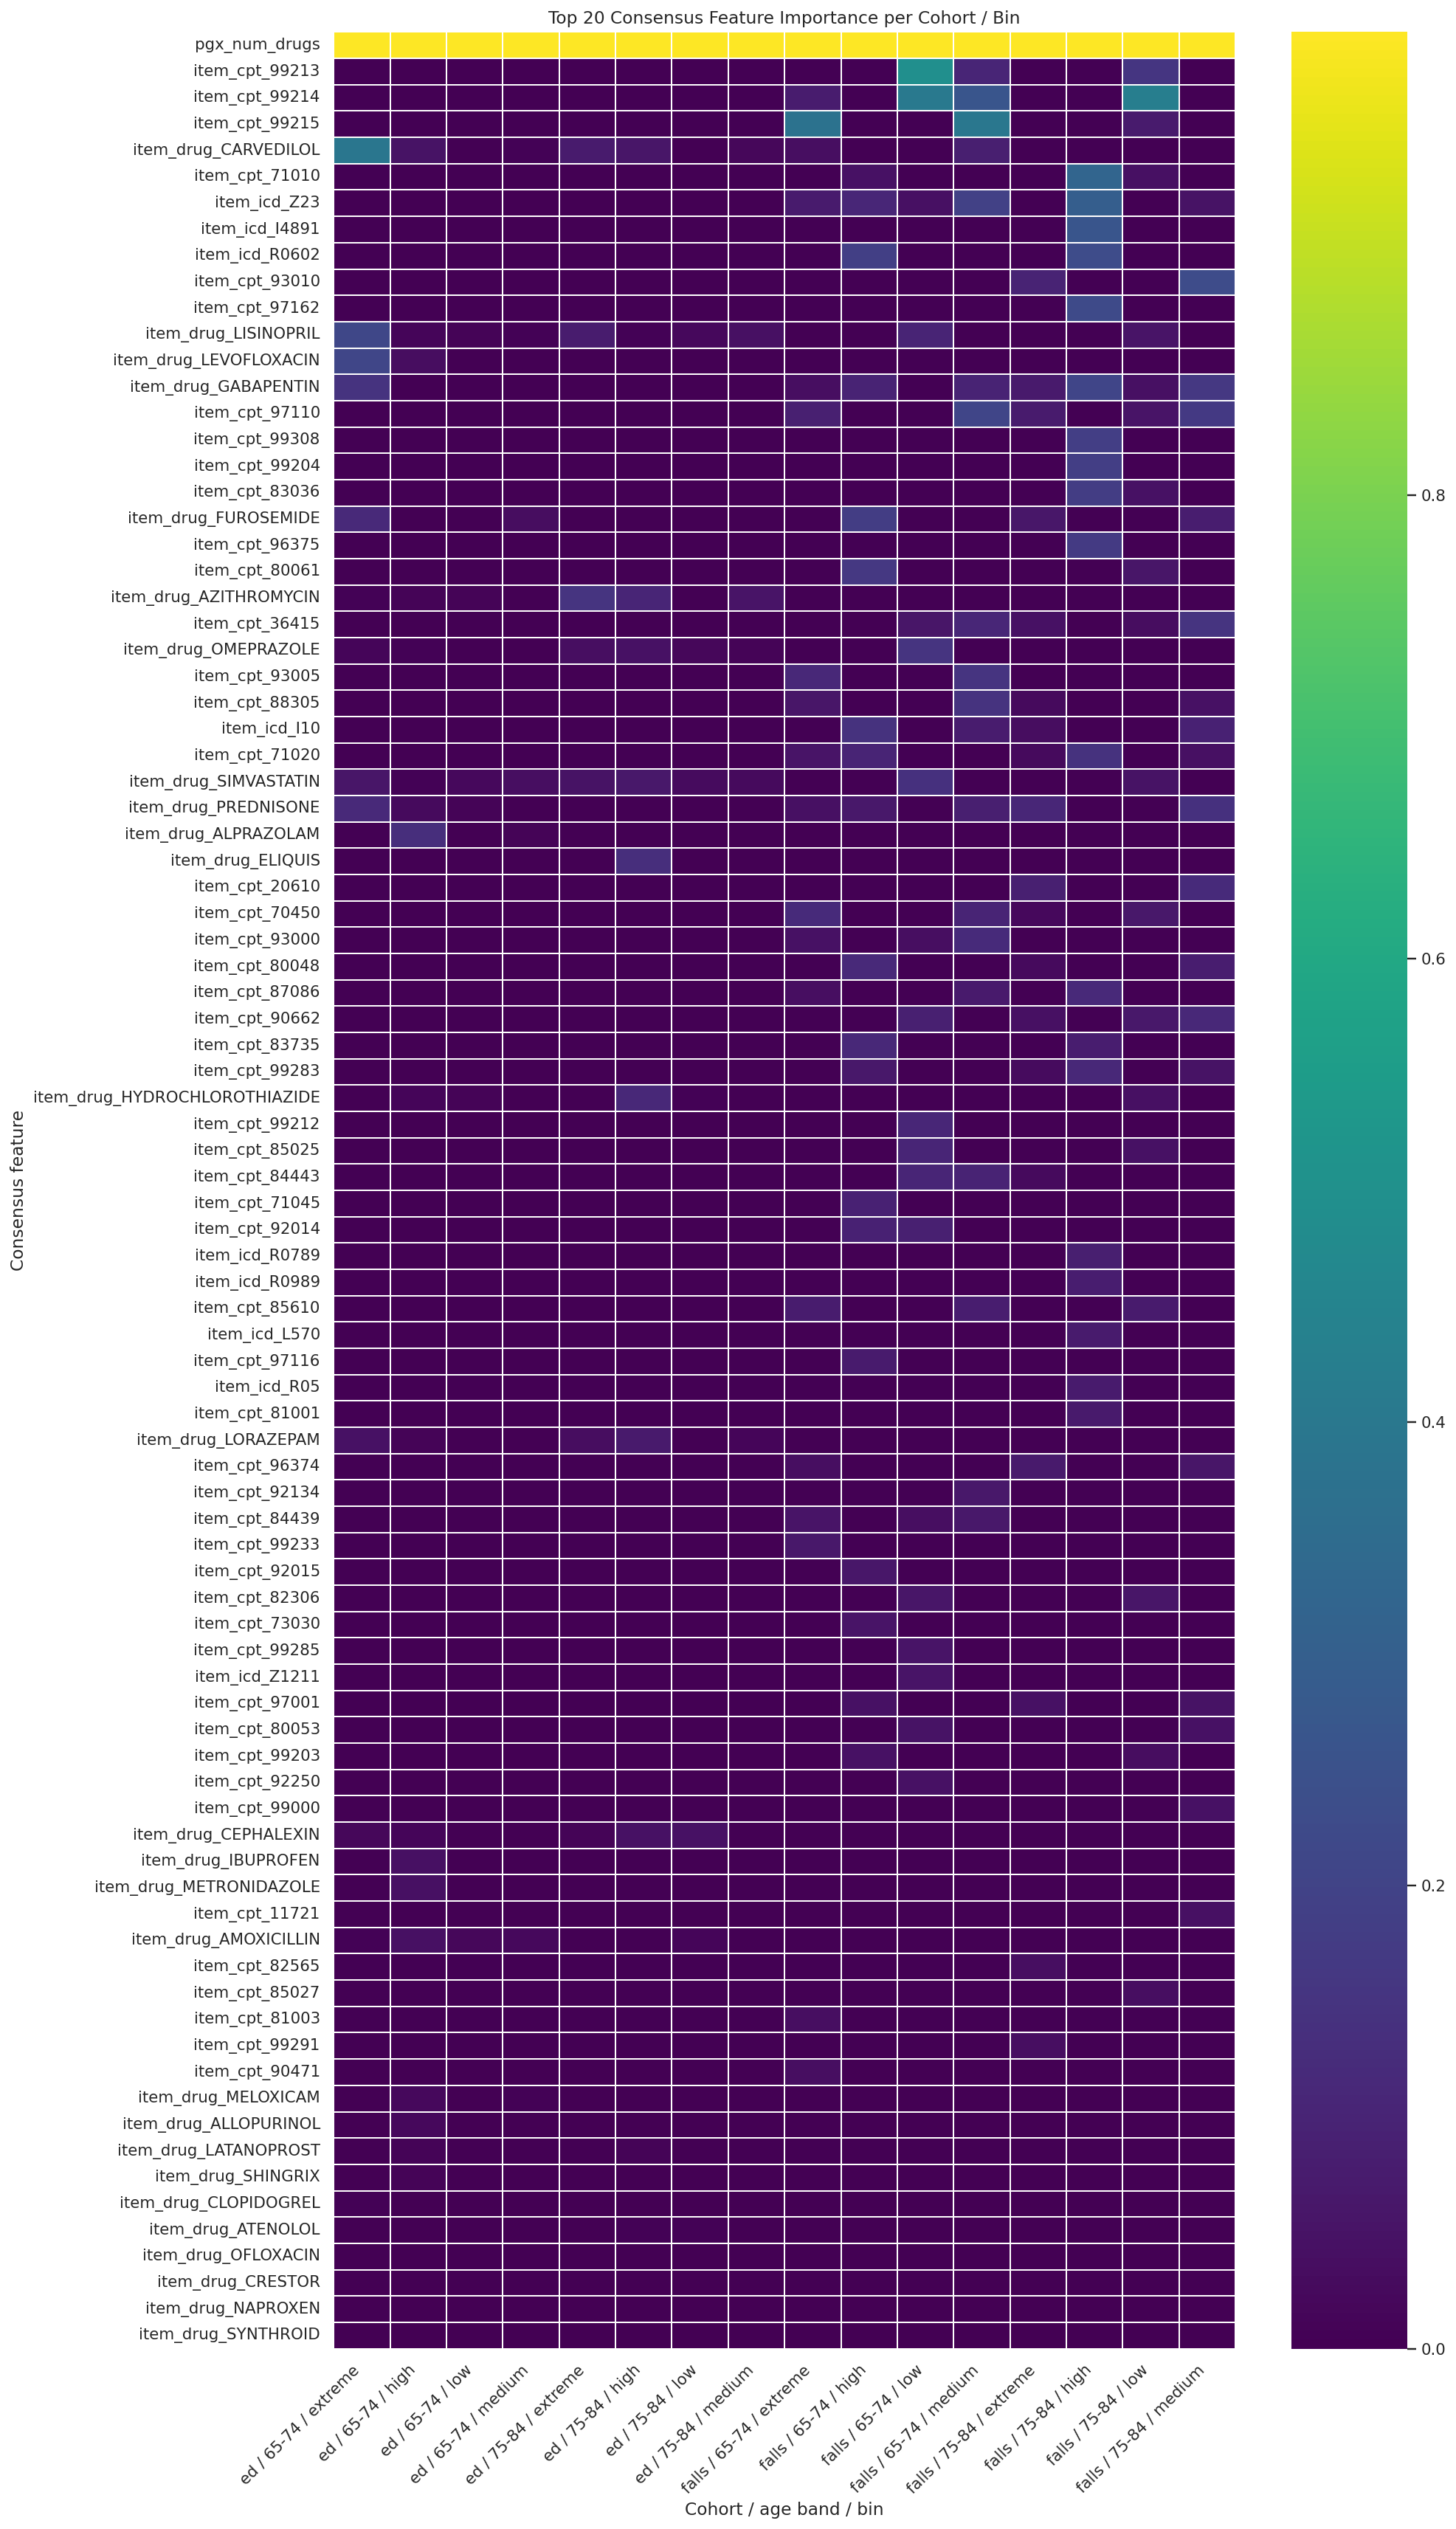

Saved review figure: 10_analysis_results/visualizations/results_review/top_20_consensus_feature_importance_1x4.png


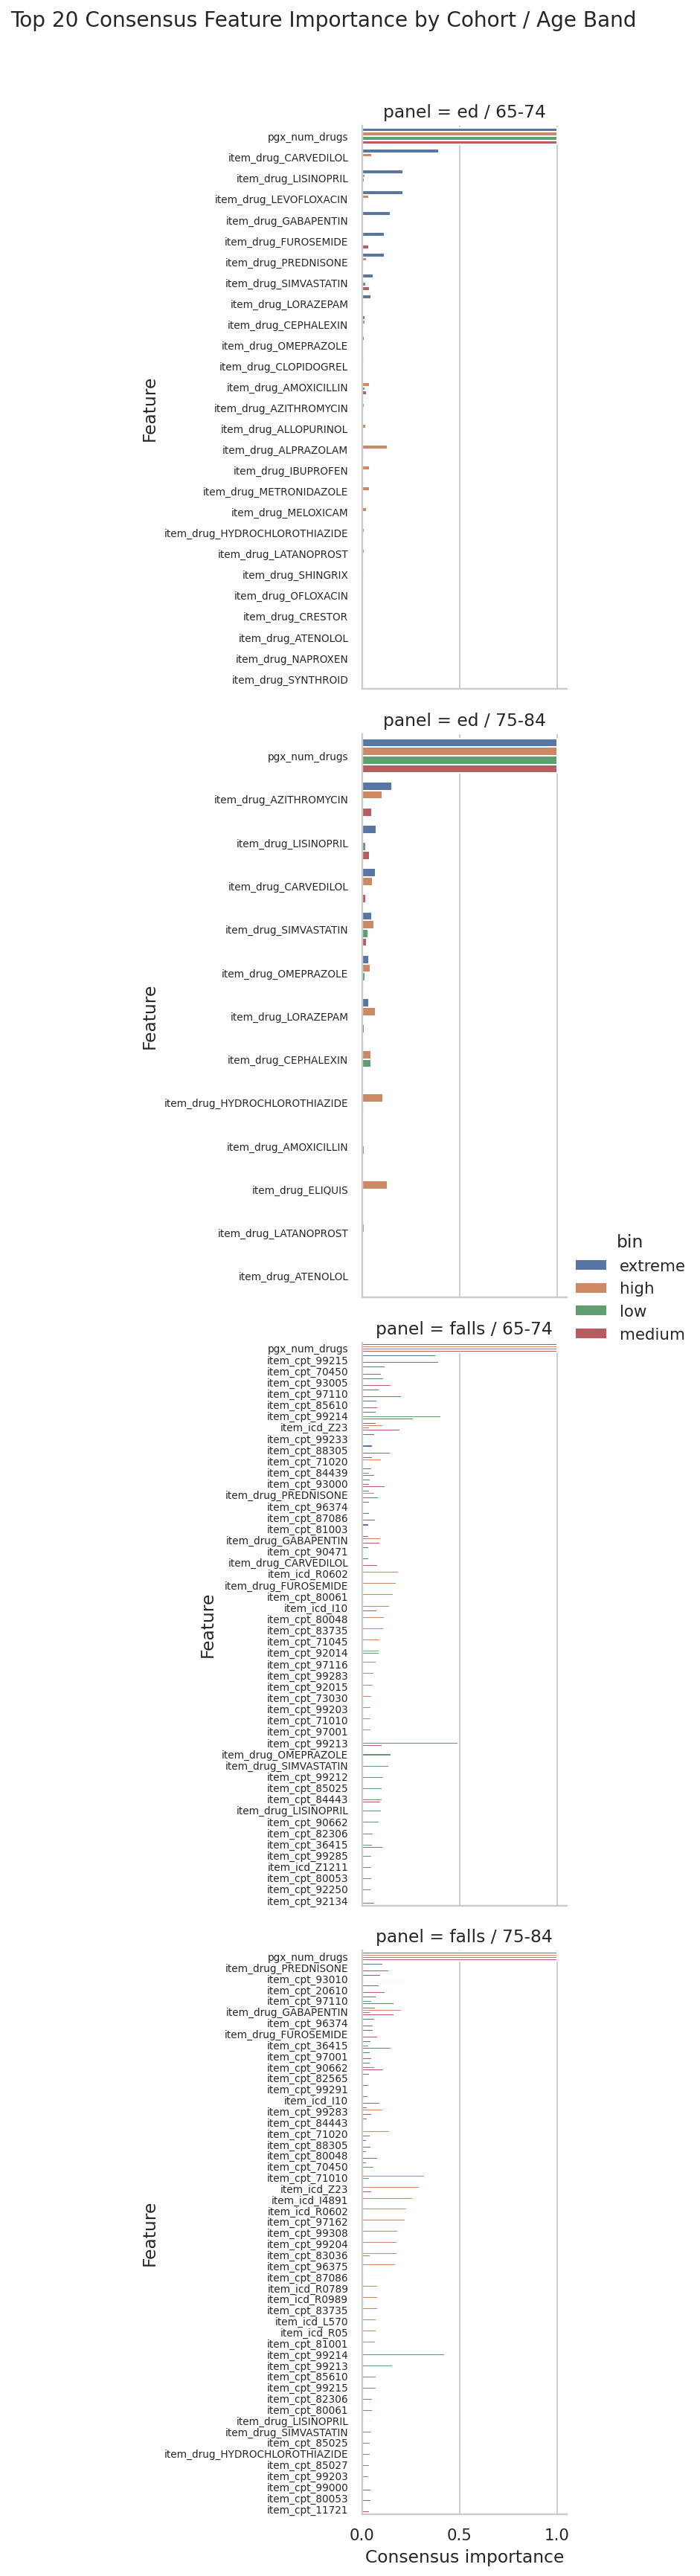

In [21]:
if combined_importance.empty:
    top20_consensus_by_bin = pd.DataFrame()
    print("No combined SHAP+FFA outputs found yet. Run Step 8 in `3_model_train_shap_ffa.ipynb`.")
else:
    top20_consensus_by_bin = (
        combined_importance
        .sort_values(["cohort", "age_band", "bin", "combined_importance", "feature"], ascending=[True, True, True, False, True])
        .groupby(["cohort", "age_band", "bin"], as_index=False, group_keys=False)
        .head(20)
        .copy()
    )
    print("Top 20 Consensus Feature Importance per cohort / age band / bin:")
    print(f"Rows shown in heatmap input: {len(top20_consensus_by_bin):,}")

    heat = top20_consensus_by_bin.copy()
    heat["panel"] = heat["cohort"] + " / " + heat["age_band"] + " / " + heat["bin"].astype(str)
    feature_order = (
        heat.groupby("feature")["combined_importance"]
        .max()
        .sort_values(ascending=False)
        .index
    )
    mat = (
        heat.pivot_table(
            index="feature",
            columns="panel",
            values="combined_importance",
            aggfunc="max",
            fill_value=0,
        )
        .reindex(feature_order)
    )
    plt.figure(figsize=(max(10, 0.9 * mat.shape[1]), max(8, 0.28 * mat.shape[0])))
    sns.heatmap(mat, cmap="viridis", linewidths=0.2, linecolor="white")
    plt.title("Top 20 Consensus Feature Importance per Cohort / Bin")
    plt.xlabel("Cohort / age band / bin")
    plt.ylabel("Consensus feature")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    save_review_figure("top_20_consensus_feature_importance_heatmap.png")
    plt.show()

    facet = top20_consensus_by_bin.copy()
    facet["panel"] = facet["cohort"] + " / " + facet["age_band"]
    g = sns.catplot(
        data=facet,
        x="combined_importance",
        y="feature",
        col="panel",
        col_wrap=1,
        hue="bin",
        kind="bar",
        sharey=False,
        height=6,
        aspect=1.0,
        errorbar=None,
    )
    g.fig.suptitle("Top 20 Consensus Feature Importance by Cohort / Age Band", y=1.03)
    g.set_axis_labels("Consensus importance", "Feature")
    for ax in g.axes.flat:
        ax.tick_params(axis="y", labelsize=7)
    figure_path = RESULTS_REVIEW_ROOT / "top_20_consensus_feature_importance_1x4.png"
    g.fig.savefig(figure_path, bbox_inches="tight", facecolor="white")
    print(f"Saved review figure: {figure_path.relative_to(PROJECT_ROOT)}")
    plt.show()

## Interaction Analysis

This section reviews interaction/scenario outputs produced by the combined SHAP+FFA workflow. It prioritizes explicit `interaction_analysis` outputs when present and otherwise uses `top_interaction_factors.csv` from the scenario artifacts.

Interaction artifact coverage:


,cohort,age_band,bin,interaction_artifact,source,rows
0,falls,65-74,low,True,10_analysis_results/visualizations/scenario/fa...,20
1,falls,65-74,medium,True,10_analysis_results/visualizations/scenario/fa...,20
2,falls,65-74,high,True,10_analysis_results/visualizations/scenario/fa...,20
3,falls,65-74,extreme,True,10_analysis_results/visualizations/scenario/fa...,20
4,falls,65-74,aggregate,False,None,0
5,falls,75-84,low,True,10_analysis_results/visualizations/scenario/fa...,20
6,falls,75-84,medium,True,10_analysis_results/visualizations/scenario/fa...,20
7,falls,75-84,high,True,10_analysis_results/visualizations/scenario/fa...,20
8,falls,75-84,extreme,True,10_analysis_results/visualizations/scenario/fa...,20
9,falls,75-84,aggregate,False,None,0


Top 20 Interaction / Scenario Factors per cohort / age band / bin:
Rows shown in heatmap input: 264
Saved review figure: 10_analysis_results/visualizations/results_review/top_20_interaction_analysis_heatmap.png


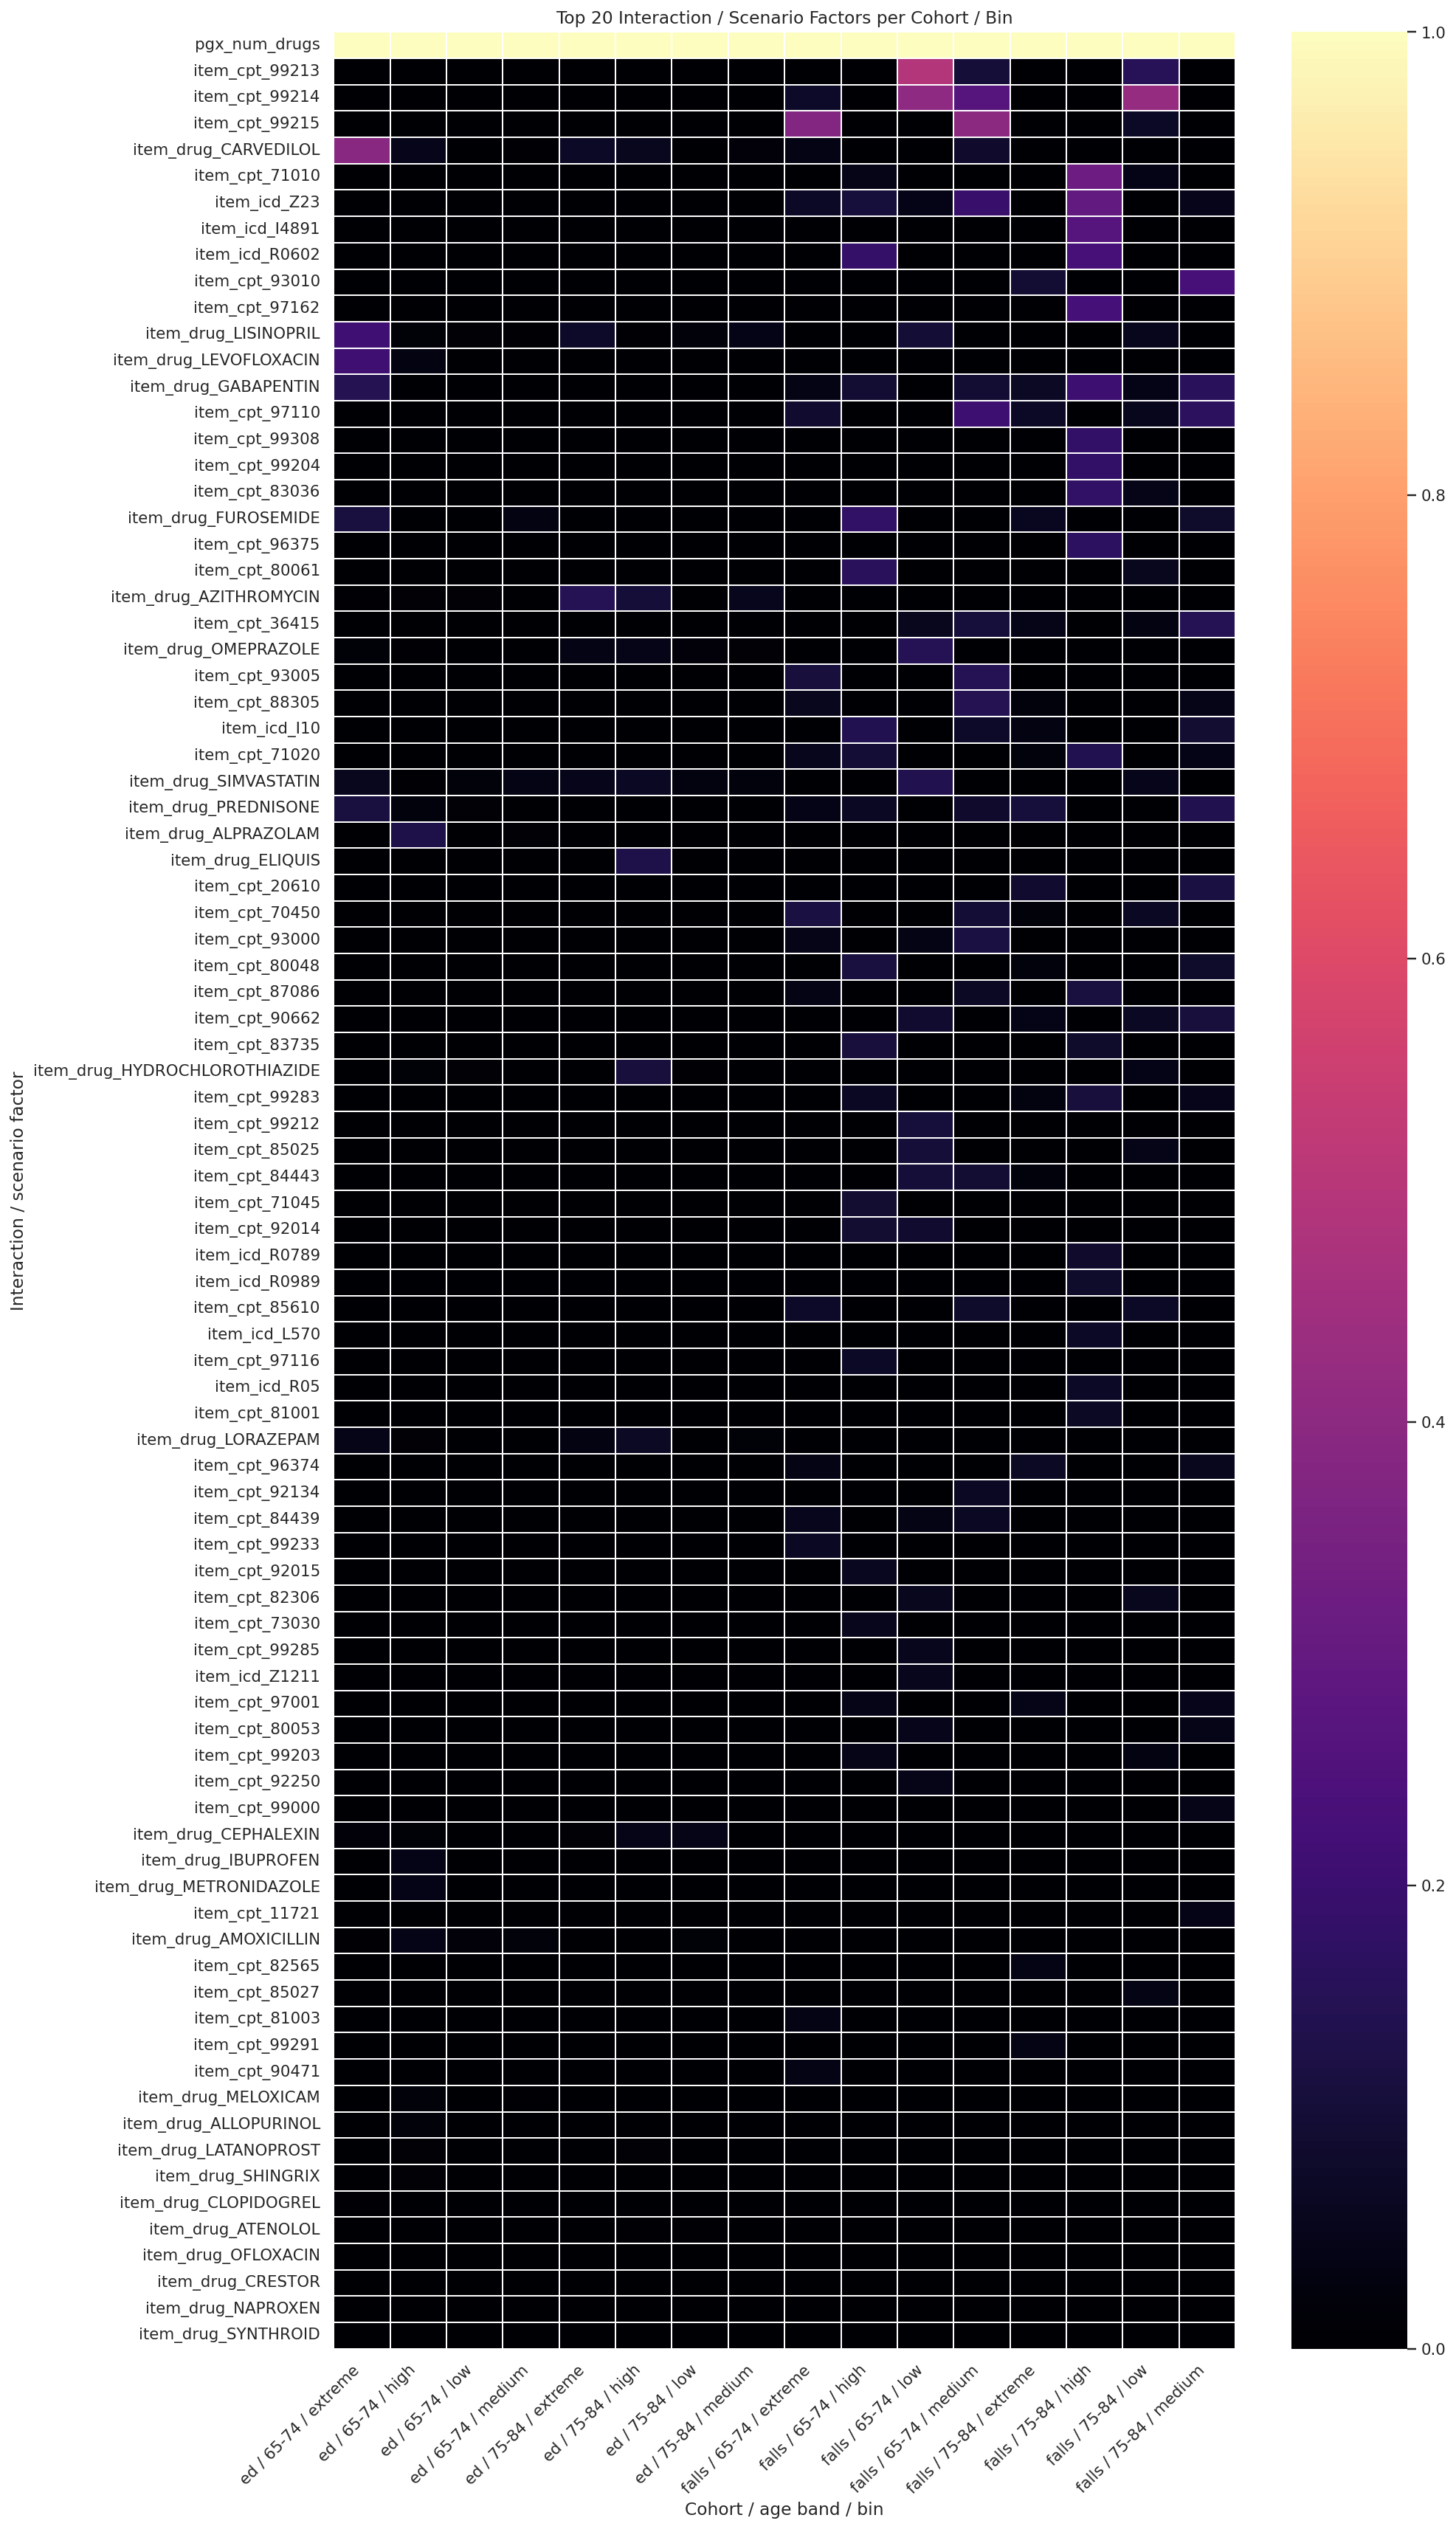

In [22]:
def _read_optional_interaction_table(paths):
    for path in paths:
        if not path.exists():
            continue
        try:
            if path.suffix.lower() == ".parquet":
                return pd.read_parquet(path), path
            return pd.read_csv(path), path
        except Exception as exc:
            print(f"[warn] Could not read interaction artifact {path}: {exc}")
    return pd.DataFrame(), None


def _interaction_label(row):
    for col in ["interaction", "feature_combination", "combination", "features", "feature_pair", "feature_tuple"]:
        if col in row and pd.notna(row[col]):
            value = row[col]
            if isinstance(value, (list, tuple, set)):
                return " + ".join(map(str, value))
            return str(value)
    if "feature" in row and pd.notna(row["feature"]):
        return str(row["feature"])
    return "unknown"


def _interaction_score_column(df):
    for col in [
        "interaction_effect",
        "interaction_responsibility",
        "combined_importance",
        "scenario_importance",
        "importance",
        "score",
    ]:
        if col in df.columns:
            return col
    numeric_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
    return numeric_cols[0] if numeric_cols else None


interaction_frames = []
interaction_status_rows = []
for _, row in artifact_inventory.iterrows():
    cohort, age_band, bin_name = row["cohort"], row["age_band"], row["bin"]
    actual_bin = None if bin_name == "aggregate" else bin_name
    scenario_dir = Path(row["scenario_dir"])
    ffa_dir = _ffa_dir(cohort, age_band, actual_bin)

    candidates = [
        ffa_dir / "xgboost" / "interaction_analysis.parquet",
        ffa_dir / "xgboost" / "interaction_analysis.csv",
        ffa_dir / "interaction_analysis.parquet",
        ffa_dir / "interaction_analysis.csv",
        scenario_dir / "interaction_analysis.parquet",
        scenario_dir / "interaction_analysis.csv",
        scenario_dir / "top_interaction_factors.csv",
    ]
    df, source_path = _read_optional_interaction_table(candidates)
    interaction_status_rows.append({
        "cohort": cohort,
        "age_band": age_band,
        "bin": bin_name,
        "interaction_artifact": source_path is not None,
        "source": str(source_path.relative_to(PROJECT_ROOT)) if source_path else None,
        "rows": len(df),
    })
    if df.empty:
        continue

    score_col = _interaction_score_column(df)
    if score_col is None:
        print(f"[warn] No numeric interaction score column found in {source_path}")
        continue

    out = df.copy()
    out["interaction_label"] = out.apply(_interaction_label, axis=1)
    out["interaction_score"] = pd.to_numeric(out[score_col], errors="coerce").fillna(0.0)
    out["score_source"] = score_col
    out["cohort"] = cohort
    out["age_band"] = age_band
    out["bin"] = bin_name
    out["source"] = str(source_path.relative_to(PROJECT_ROOT)) if source_path else None
    interaction_frames.append(out)

interaction_status = pd.DataFrame(interaction_status_rows)
print("Interaction artifact coverage:")
display(interaction_status)

if interaction_frames:
    interaction_analysis = pd.concat(interaction_frames, ignore_index=True)
    top20_interactions_by_bin = (
        interaction_analysis
        .sort_values(["cohort", "age_band", "bin", "interaction_score", "interaction_label"], ascending=[True, True, True, False, True])
        .groupby(["cohort", "age_band", "bin"], as_index=False, group_keys=False)
        .head(20)
        .copy()
    )
    print("Top 20 Interaction / Scenario Factors per cohort / age band / bin:")
    print(f"Rows shown in heatmap input: {len(top20_interactions_by_bin):,}")

    heat = top20_interactions_by_bin.copy()
    heat["panel"] = heat["cohort"] + " / " + heat["age_band"] + " / " + heat["bin"].astype(str)
    interaction_order = (
        heat.groupby("interaction_label")["interaction_score"]
        .max()
        .sort_values(ascending=False)
        .index
    )
    mat = (
        heat.pivot_table(
            index="interaction_label",
            columns="panel",
            values="interaction_score",
            aggfunc="max",
            fill_value=0,
        )
        .reindex(interaction_order)
    )
    plt.figure(figsize=(max(10, 0.9 * mat.shape[1]), max(8, 0.28 * mat.shape[0])))
    sns.heatmap(mat, cmap="magma", linewidths=0.2, linecolor="white")
    plt.title("Top 20 Interaction / Scenario Factors per Cohort / Bin")
    plt.xlabel("Cohort / age band / bin")
    plt.ylabel("Interaction / scenario factor")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    save_review_figure("top_20_interaction_analysis_heatmap.png")
    plt.show()
else:
    interaction_analysis = pd.DataFrame()
    top20_interactions_by_bin = pd.DataFrame()
    print("No interaction/scenario artifacts found yet. Run Step 8 in `3_model_train_shap_ffa.ipynb`.")

## Consensus, Feature Types, and Patient Explanations

These checks follow the FFA analysis reference: consensus features indicate agreement between SHAP and FFA, feature-type mix helps verify whether the result is driven by drugs, diagnoses, procedures, or other model features, and patient explanations show how often global consensus features appear in individual explanations.

,cohort,age_band,bin,consensus_count,shap_count,ffa_count,consensus_rate
0,falls,65-74,low,17,20,20,0.85
1,falls,65-74,medium,19,20,20,0.95
2,falls,65-74,high,20,20,20,1.00
3,falls,65-74,extreme,15,20,20,0.75
4,falls,75-84,low,17,20,20,0.85
5,falls,75-84,medium,19,20,20,0.95
6,falls,75-84,high,19,20,20,0.95
7,falls,75-84,extreme,17,20,20,0.85
8,ed,65-74,low,8,8,8,0.40
9,ed,65-74,medium,20,20,20,1.00


Saved review figure: 10_analysis_results/visualizations/results_review/consensus_feature_counts.png


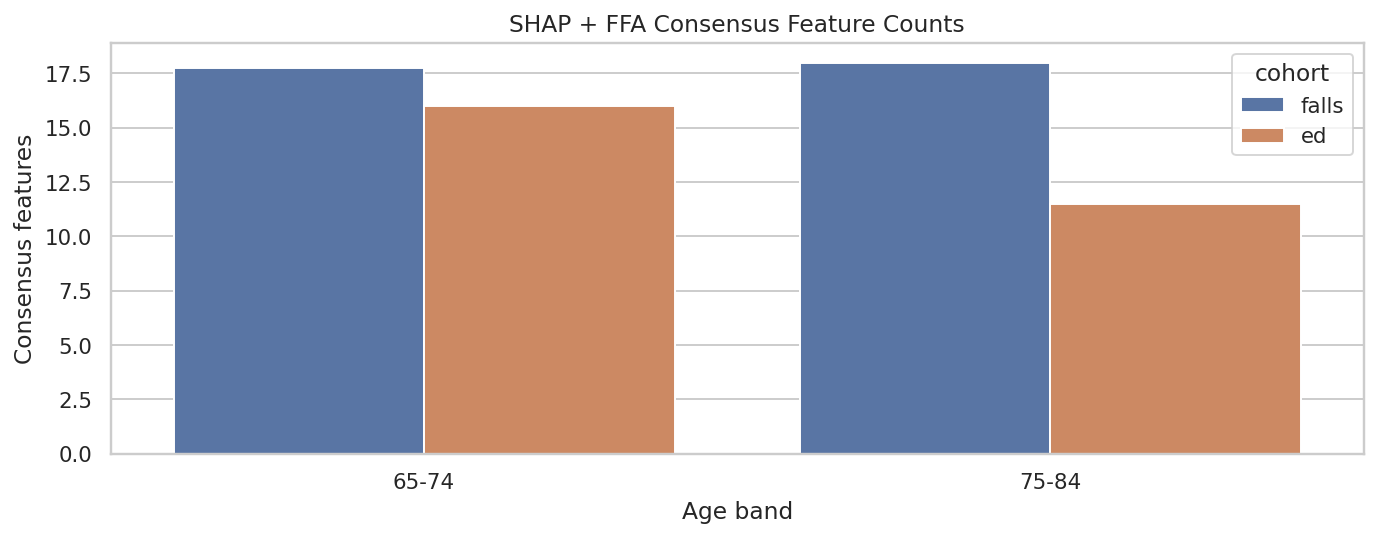

In [23]:
if consensus_summary.empty:
    print("No consensus feature JSON files found yet.")
else:
    cols = [c for c in ["cohort", "age_band", "bin", "consensus_count", "shap_count", "ffa_count", "consensus_rate"] if c in consensus_summary.columns]
    display(consensus_summary[cols])
    plt.figure(figsize=(10, 4))
    sns.barplot(data=consensus_summary, x="age_band", y="consensus_count", hue="cohort", errorbar=None)
    plt.title("SHAP + FFA Consensus Feature Counts")
    plt.xlabel("Age band")
    plt.ylabel("Consensus features")
    plt.tight_layout()
    save_review_figure("consensus_feature_counts.png")
    plt.show()

,cohort,age_band,bin,feature_type,n_features
0,ed,65-74,extreme,drug,15
1,ed,65-74,extreme,pgx,1
2,ed,65-74,high,drug,25
3,ed,65-74,high,pgx,1
4,ed,65-74,low,drug,7
5,ed,65-74,low,pgx,1
6,ed,65-74,medium,drug,30
7,ed,65-74,medium,pgx,1
8,ed,75-84,extreme,drug,9
9,ed,75-84,extreme,pgx,1


Saved review figure: 10_analysis_results/visualizations/results_review/combined_feature_type_mix.png


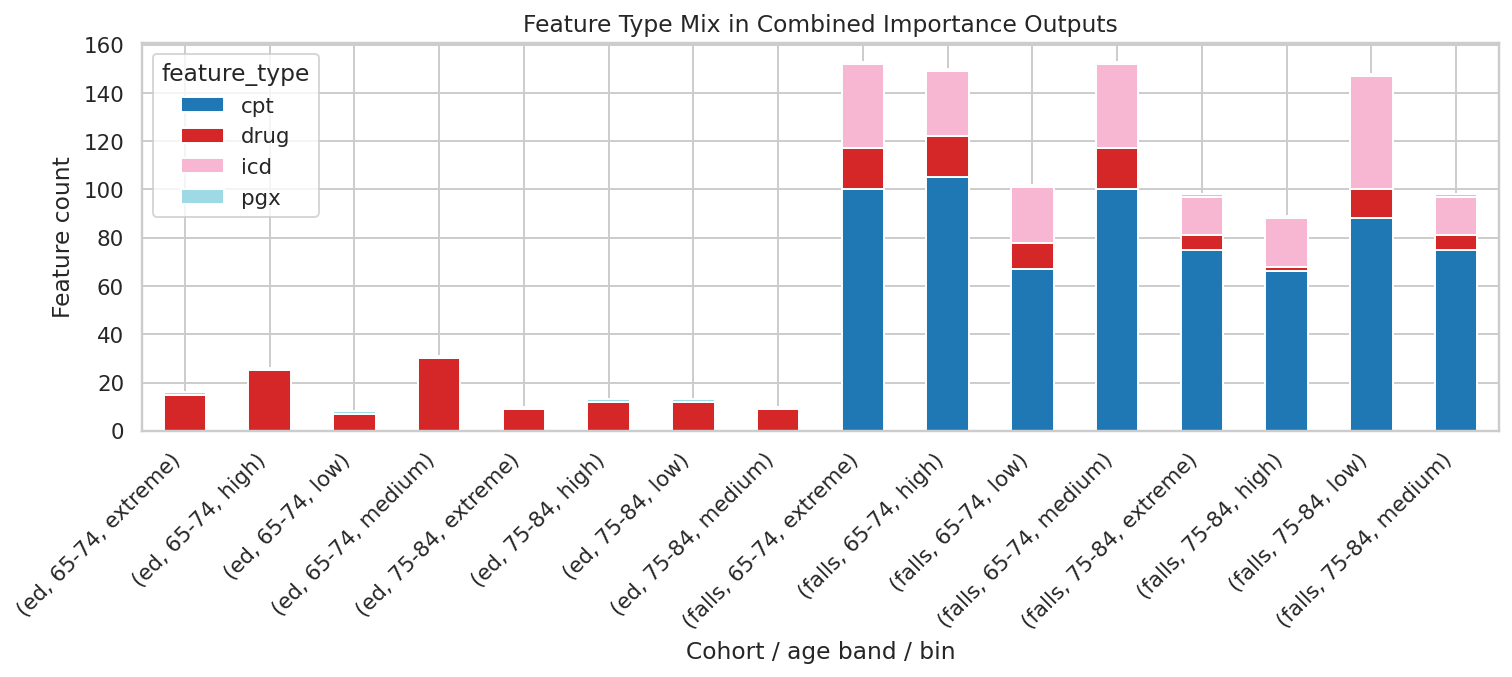

In [24]:
def feature_type(feature):
    feature = str(feature)
    if feature.startswith(("item_drug_", "drug_")):
        return "drug"
    if feature.startswith(("item_icd_", "icd_")):
        return "icd"
    if feature.startswith(("item_cpt_", "cpt_")):
        return "cpt"
    if feature.startswith("pgx_") or "pgx" in feature.lower():
        return "pgx"
    return "other"

if not combined_importance.empty:
    ft = combined_importance.copy()
    ft["feature_type"] = ft["feature"].map(feature_type)
    ft_counts = (ft.groupby(["cohort", "age_band", "bin", "feature_type"])
                   .size().reset_index(name="n_features"))
    display(ft_counts)
    pivot = ft_counts.pivot_table(index=["cohort", "age_band", "bin"], columns="feature_type", values="n_features", fill_value=0)
    pivot.plot(kind="bar", stacked=True, figsize=(11, 5), colormap="tab20")
    plt.title("Feature Type Mix in Combined Importance Outputs")
    plt.xlabel("Cohort / age band / bin")
    plt.ylabel("Feature count")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    save_review_figure("combined_feature_type_mix.png")
    plt.show()

,cohort,age_band,bin,n_patient_explanations,n_with_consensus,n_consensus_feature_hits,mean_consensus_features_per_patient,median_consensus_features_per_patient,max_consensus_features_per_patient,pct_with_consensus
0,falls,65-74,low,377,377,1887,5.005305,5.0,9,1.0
1,falls,65-74,medium,266,266,1574,5.917293,6.0,10,1.0
2,falls,65-74,high,286,286,1647,5.758741,6.0,10,1.0
3,falls,65-74,extreme,27,27,184,6.814815,7.0,10,1.0
4,falls,75-84,low,474,474,2546,5.371308,5.0,9,1.0
5,falls,75-84,medium,351,351,1912,5.447293,5.0,10,1.0
6,falls,75-84,high,352,352,2092,5.943182,6.0,10,1.0
7,falls,75-84,extreme,23,23,124,5.391304,5.0,8,1.0
8,ed,65-74,low,1890,1890,15120,8.000000,8.0,8,1.0
9,ed,65-74,medium,744,744,7185,9.657258,10.0,10,1.0


Saved review figure: 10_analysis_results/visualizations/results_review/patient_explanations_consensus.png


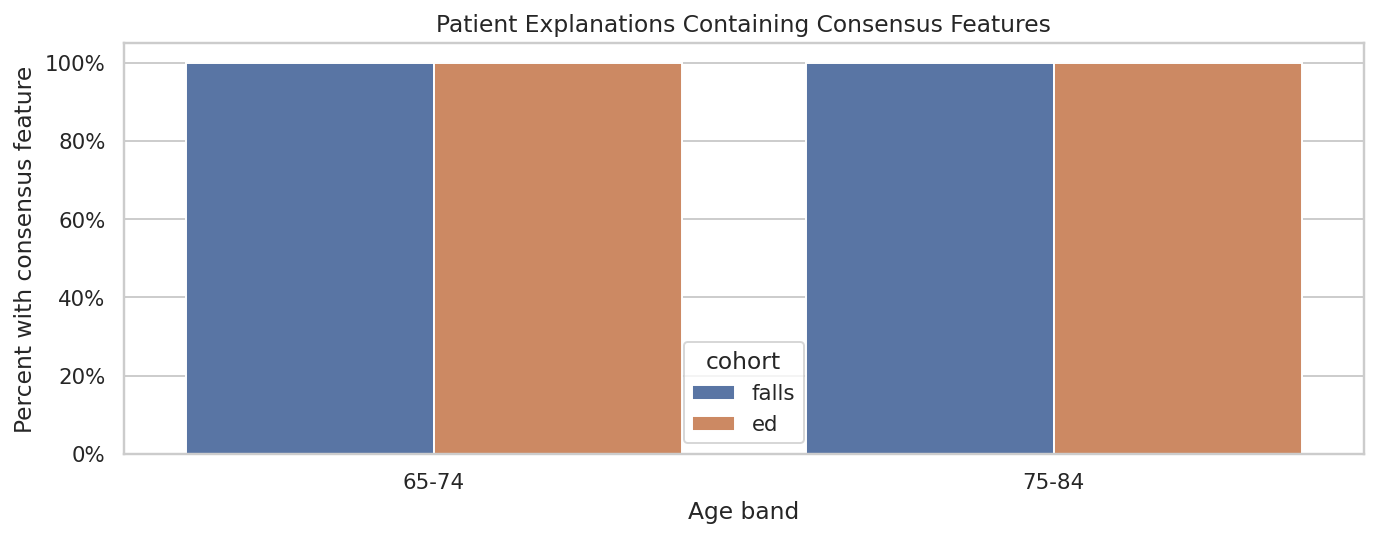

In [26]:
if patient_summary.empty:
    print("No patient explanation summaries found yet.")
else:
    patient_summary["pct_with_consensus"] = np.where(
        patient_summary["n_patient_explanations"] > 0,
        patient_summary["n_with_consensus"] / patient_summary["n_patient_explanations"],
        0,
    )
    display(patient_summary)
    plt.figure(figsize=(10, 4))
    sns.barplot(data=patient_summary, x="age_band", y="pct_with_consensus", hue="cohort", errorbar=None)
    plt.title("Patient Explanations Containing Consensus Features")
    plt.xlabel("Age band")
    plt.ylabel("Percent with consensus feature")
    plt.gca().yaxis.set_major_formatter(lambda x, _: f"{x:.0%}")
    plt.tight_layout()
    save_review_figure("patient_explanations_consensus.png")
    plt.show()

## SHAP vs FFA Agreement

The scatter below compares normalized SHAP importance and normalized FFA importance. Features in the upper-right are candidates for stronger review because both methods rank them highly.

Saved review figure: 10_analysis_results/visualizations/results_review/shap_vs_ffa_agreement.png


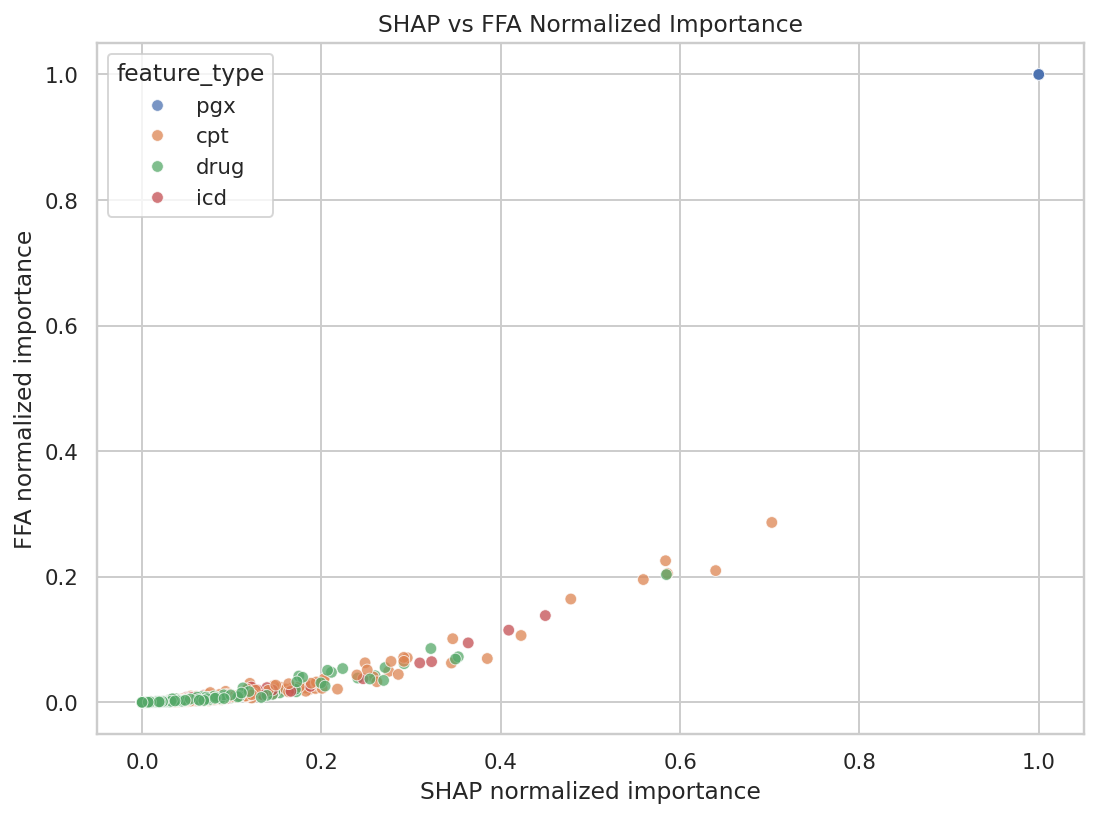

,cohort,age_band,bin,feature,feature_type,shap_norm,ffa_norm,combined_importance
1072,ed,75-84,low,pgx_num_drugs,pgx,1.000000,1.000000,1.000000
991,ed,65-74,low,pgx_num_drugs,pgx,1.000000,1.000000,1.000000
999,ed,65-74,medium,pgx_num_drugs,pgx,1.000000,1.000000,1.000000
1085,ed,75-84,medium,pgx_num_drugs,pgx,1.000000,1.000000,1.000000
1108,ed,75-84,extreme,pgx_num_drugs,pgx,1.000000,1.000000,1.000000
1030,ed,65-74,high,pgx_num_drugs,pgx,1.000000,1.000000,1.000000
1095,ed,75-84,high,pgx_num_drugs,pgx,1.000000,1.000000,1.000000
1056,ed,65-74,extreme,pgx_num_drugs,pgx,1.000000,1.000000,1.000000
893,falls,75-84,extreme,pgx_num_drugs,pgx,1.000000,1.000000,1.000000
255,falls,65-74,high,pgx_num_drugs,pgx,1.000000,1.000000,1.000000


In [27]:
if not combined_importance.empty and {"shap_norm", "ffa_norm"}.issubset(combined_importance.columns):
    plot_df = combined_importance.copy()
    plot_df["feature_type"] = plot_df["feature"].map(feature_type)
    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=plot_df, x="shap_norm", y="ffa_norm", hue="feature_type", alpha=0.75)
    plt.title("SHAP vs FFA Normalized Importance")
    plt.xlabel("SHAP normalized importance")
    plt.ylabel("FFA normalized importance")
    plt.tight_layout()
    save_review_figure("shap_vs_ffa_agreement.png")
    plt.show()

    display(plot_df.sort_values("combined_importance", ascending=False)[
        ["cohort", "age_band", "bin", "feature", "feature_type", "shap_norm", "ffa_norm", "combined_importance"]
    ].head(30))

## Cohort PGx NetworkX Workflow

This section can regenerate the cohort PGx artifacts from notebook 4. It fetches PharmGKB/ClinPGx VIP report data, resolves top SHAP/FFA Consensus Filter drug features to CPIC genes, builds the NetworkX topology, writes interactive HTML, and exports GitHub-renderable PNG previews.

Set `RUN_PGX_NETWORK_WORKFLOW = True` to rerun the workflow. The default is `False` so opening or rerunning the notebook does not repeatedly call external PharmGKB/ClinPGx endpoints.

In [ ]:
# Run Cohort PGx VIP fetch + NetworkX build from Notebook 4.
# Defaults avoid repeated external API calls during routine notebook reruns.
import json
import subprocess
import sys
from pathlib import Path

import pandas as pd
from IPython.display import Image, Markdown, display

RUN_PGX_NETWORK_WORKFLOW = False
FORCE_PGX_VIP_REPORTS = False
FETCH_PGX_VIP_PAGES = True
PGX_TOP_N = 50
PGX_USE_COMPREHEND = False
UPLOAD_PGX_NETWORKS = False
RUN_PGX_FIGURE_PACK = True

PGX_COHORT_AGE_BANDS = [
    ("falls", "65-74"),
    ("falls", "75-84"),
    ("ed", "65-74"),
    ("ed", "75-84"),
]

pgx_dir = PROJECT_ROOT / "10_analysis_results" / "cohort_pgx"
pgx_reports_dir = PROJECT_ROOT / "10_analysis_results" / "visualizations" / "cohort_pgx" / "reports"
pgx_networks_dir = PROJECT_ROOT / "10_analysis_results" / "visualizations" / "cohort_pgx" / "networks"
fetch_vip_script = pgx_dir / "fetch_vip_reports.py"
build_network_script = pgx_dir / "build_network_topology.py"
figure_pack_script = pgx_dir / "generate_network_figure_pack.py"
pgx_figure_pack_dir = PROJECT_ROOT / "10_analysis_results" / "visualizations" / "cohort_pgx" / "figure_pack"
pgx_reports_dir.mkdir(parents=True, exist_ok=True)
pgx_networks_dir.mkdir(parents=True, exist_ok=True)


def _run_pgx_command(cmd, label):
    print(f"\n{'=' * 80}\n{label}\n{' '.join(str(part) for part in cmd)}")
    result = subprocess.run(
        cmd,
        cwd=PROJECT_ROOT,
        text=True,
        capture_output=True,
    )
    if result.stdout:
        print(result.stdout[-6000:])
    if result.stderr:
        print(result.stderr[-6000:])
    if result.returncode != 0:
        raise RuntimeError(f"{label} failed with exit code {result.returncode}.")


if RUN_PGX_NETWORK_WORKFLOW:
    for cohort, age_band in PGX_COHORT_AGE_BANDS:
        age_band_fname = age_band_to_fname(age_band)
        fetch_cmd = [
            sys.executable,
            str(fetch_vip_script),
            "--cohort",
            cohort,
            "--age-band",
            age_band,
            "--top-n",
            str(PGX_TOP_N),
            "--project-root",
            str(PROJECT_ROOT),
            "--output-dir",
            str(pgx_reports_dir),
        ]
        if FORCE_PGX_VIP_REPORTS:
            fetch_cmd.append("--force")
        if not FETCH_PGX_VIP_PAGES:
            fetch_cmd.append("--no-vip-pages")
        _run_pgx_command(fetch_cmd, f"Fetch VIP reports: {cohort} / {age_band}")

        reports_file = pgx_reports_dir / f"{cohort}_{age_band_fname}_vip_reports.json"
        seed_edges_file = pgx_reports_dir / f"{cohort}_{age_band_fname}_seed_drug_gene_edges.csv"
        output_dir = pgx_networks_dir / cohort / age_band_fname
        build_cmd = [
            sys.executable,
            str(build_network_script),
            "--reports",
            str(reports_file),
            "--output-dir",
            str(output_dir),
            "--cohort",
            cohort,
            "--age-band",
            age_band,
        ]
        if seed_edges_file.exists():
            build_cmd.extend(["--seed-drug-edges", str(seed_edges_file)])
        if not PGX_USE_COMPREHEND:
            build_cmd.append("--no-comprehend")
        if not UPLOAD_PGX_NETWORKS:
            build_cmd.append("--no-upload")
        _run_pgx_command(build_cmd, f"Build PGx NetworkX topology: {cohort} / {age_band}")
else:
    print("PGx network workflow skipped because RUN_PGX_NETWORK_WORKFLOW=False.")
    print("Set it to True to fetch VIP reports and build per-cohort NetworkX outputs.")

if RUN_PGX_FIGURE_PACK:
    figure_cmd = [
        sys.executable,
        str(figure_pack_script),
        "--project-root",
        str(PROJECT_ROOT),
    ]
    _run_pgx_command(figure_cmd, "Generate PGx publication figure pack")
else:
    print("PGx figure pack generation skipped because RUN_PGX_FIGURE_PACK=False.")

pgx_rows = []
for cohort, age_band in PGX_COHORT_AGE_BANDS:
    age_band_fname = age_band_to_fname(age_band)
    reports_file = pgx_reports_dir / f"{cohort}_{age_band_fname}_vip_reports.json"
    summary_file = pgx_reports_dir / f"{cohort}_{age_band_fname}_vip_reports_summary.json"
    seed_edges_file = pgx_reports_dir / f"{cohort}_{age_band_fname}_seed_drug_gene_edges.csv"
    network_dir = pgx_networks_dir / cohort / age_band_fname
    stats_file = network_dir / "network_stats.json"
    html_file = network_dir / "network_topology.html"
    png_file = network_dir / "network_topology.png"
    summary = json.loads(summary_file.read_text(encoding="utf-8")) if summary_file.exists() else {}
    stats = json.loads(stats_file.read_text(encoding="utf-8")) if stats_file.exists() else {}
    pgx_rows.append({
        "cohort": cohort,
        "age_band": age_band,
        "reports": summary.get("reports_fetched"),
        "missing_vip_summary": summary.get("genes_missing_vip_summary"),
        "valid_vip_summary_schema": summary.get("genes_with_valid_vip_summary_schema"),
        "vip_page_text": summary.get("genes_with_vip_page_text"),
        "any_text": summary.get("genes_with_any_text"),
        "seed_edges": stats.get("seed_drug_gene_edges"),
        "nodes": stats.get("nodes_total"),
        "edges": stats.get("edges_total"),
        "reports_json": reports_file.exists(),
        "seed_edges_csv": seed_edges_file.exists(),
        "network_html": html_file.exists(),
        "network_png": png_file.exists(),
        "html_path": str(html_file.relative_to(PROJECT_ROOT)) if html_file.exists() else "",
        "png_path": str(png_file.relative_to(PROJECT_ROOT)) if png_file.exists() else "",
    })

pgx_network_summary = pd.DataFrame(pgx_rows)
display(pgx_network_summary)

figure_pack_manifest_file = pgx_figure_pack_dir / "figure_pack_manifest.json"
figure_pack_manifest = json.loads(figure_pack_manifest_file.read_text(encoding="utf-8")) if figure_pack_manifest_file.exists() else {}
print("PGx figure pack manifest:", figure_pack_manifest_file.relative_to(PROJECT_ROOT) if figure_pack_manifest_file.exists() else "not found")


In [ ]:
# Display GitHub-friendly static PGx network previews and figure-pack visuals.
from IPython.display import Image, Markdown, display

for _, row in pgx_network_summary.iterrows():
    title = f"{row['cohort']} {row['age_band']} PGx Network"
    png_path = PROJECT_ROOT / row["png_path"] if row.get("png_path") else None
    html_path = row.get("html_path", "")
    display(Markdown(f"### {title}"))
    if png_path and png_path.exists():
        display(Image(filename=str(png_path), width=850))
        if html_path:
            display(Markdown(f"Interactive HTML artifact: `{html_path}`"))
    else:
        display(Markdown("PNG preview not found. Run the PGx workflow cell with `RUN_PGX_NETWORK_WORKFLOW=True`."))

figure_pack_previews = [
    ("Intervention-weighted global network", "pgx_global_intervention_network"),
    ("Cohort small multiples", "pgx_cohort_small_multiples"),
    ("Therapeutic cluster ego networks", "pgx_cluster_ego_networks"),
    ("Intervention priority heatmap", "pgx_intervention_priority_heatmap"),
    ("Medication lead-time panel", "pgx_time_to_event_panel"),
]

display(Markdown("## PGx Publication Figure Pack"))
for title, stem in figure_pack_previews:
    png_path = pgx_figure_pack_dir / f"{stem}.png"
    html_path = pgx_figure_pack_dir / f"{stem}.html"
    display(Markdown(f"### {title}"))
    if png_path.exists():
        display(Image(filename=str(png_path), width=900))
        display(Markdown(f"Interactive HTML artifact: `{html_path.relative_to(PROJECT_ROOT)}`"))
    else:
        display(Markdown(f"Figure-pack preview not found: `{png_path.relative_to(PROJECT_ROOT)}`"))


### GitHub-Renderable PGx Network and Figure-Pack Previews

The static PNG previews below render directly in GitHub and link to the interactive Plotly HTML artifacts for local/S3 viewing.

#### Per-Cohort NetworkX Previews

[![Falls 65-74 PGx Network](10_analysis_results/visualizations/cohort_pgx/networks/falls/65_74/network_topology.png)](10_analysis_results/visualizations/cohort_pgx/networks/falls/65_74/network_topology.html)

[![Falls 75-84 PGx Network](10_analysis_results/visualizations/cohort_pgx/networks/falls/75_84/network_topology.png)](10_analysis_results/visualizations/cohort_pgx/networks/falls/75_84/network_topology.html)

[![ED 65-74 PGx Network](10_analysis_results/visualizations/cohort_pgx/networks/ed/65_74/network_topology.png)](10_analysis_results/visualizations/cohort_pgx/networks/ed/65_74/network_topology.html)

[![ED 75-84 PGx Network](10_analysis_results/visualizations/cohort_pgx/networks/ed/75_84/network_topology.png)](10_analysis_results/visualizations/cohort_pgx/networks/ed/75_84/network_topology.html)

#### Publication-Oriented Figure Pack

[![PGx Global Intervention Network](10_analysis_results/visualizations/cohort_pgx/figure_pack/pgx_global_intervention_network.png)](10_analysis_results/visualizations/cohort_pgx/figure_pack/pgx_global_intervention_network.html)

[![PGx Cohort Small Multiples](10_analysis_results/visualizations/cohort_pgx/figure_pack/pgx_cohort_small_multiples.png)](10_analysis_results/visualizations/cohort_pgx/figure_pack/pgx_cohort_small_multiples.html)

[![PGx Cluster Ego Networks](10_analysis_results/visualizations/cohort_pgx/figure_pack/pgx_cluster_ego_networks.png)](10_analysis_results/visualizations/cohort_pgx/figure_pack/pgx_cluster_ego_networks.html)

[![PGx Intervention Priority Heatmap](10_analysis_results/visualizations/cohort_pgx/figure_pack/pgx_intervention_priority_heatmap.png)](10_analysis_results/visualizations/cohort_pgx/figure_pack/pgx_intervention_priority_heatmap.html)

[![PGx Time-to-Event Panel](10_analysis_results/visualizations/cohort_pgx/figure_pack/pgx_time_to_event_panel.png)](10_analysis_results/visualizations/cohort_pgx/figure_pack/pgx_time_to_event_panel.html)


## Persist and Sync Results Artifacts

This cell writes review tables and saved figures under `10_analysis_results/visualizations/results_review/`, then syncs both the combined scenario artifacts and Results notebook visualizations to project-scoped S3:

- `s3://{S3_BUCKET}/gold/{PROJECT_SLUG}/analysis_visuals/scenario/`
- `s3://{S3_BUCKET}/gold/{PROJECT_SLUG}/analysis_visuals/results_review/`

In [28]:
# Persist tabular review outputs locally for S3 sync.
review_tables = {
    "artifact_inventory.csv": artifact_inventory if "artifact_inventory" in globals() else pd.DataFrame(),
    "dtw_summary.csv": dtw_summary if "dtw_summary" in globals() else pd.DataFrame(),
    "dtw_cohort_comparison.csv": dtw_cohort_comparison if "dtw_cohort_comparison" in globals() else pd.DataFrame(),
    "dtw_json_summary.csv": dtw_json_summary if "dtw_json_summary" in globals() else pd.DataFrame(),
    "dtw_json_trajectory_rates.csv": dtw_json_trajectory_rates if "dtw_json_trajectory_rates" in globals() else pd.DataFrame(),
    "dtw_json_sequence_counts.csv": dtw_json_sequence_counts if "dtw_json_sequence_counts" in globals() else pd.DataFrame(),
    "model_metrics.csv": model_metrics if "model_metrics" in globals() else pd.DataFrame(),
    "best_model_metrics.csv": best_model_metrics if "best_model_metrics" in globals() else pd.DataFrame(),
    "combined_importance.csv": combined_importance if "combined_importance" in globals() else pd.DataFrame(),
    "top20_consensus_by_bin.csv": top20_consensus_by_bin if "top20_consensus_by_bin" in globals() else pd.DataFrame(),
    "interaction_status.csv": interaction_status if "interaction_status" in globals() else pd.DataFrame(),
    "top20_interactions_by_bin.csv": top20_interactions_by_bin if "top20_interactions_by_bin" in globals() else pd.DataFrame(),
    "consensus_summary.csv": consensus_summary if "consensus_summary" in globals() else pd.DataFrame(),
    "patient_summary.csv": patient_summary if "patient_summary" in globals() else pd.DataFrame(),
    "dashboard_summary.csv": dashboard_summary if "dashboard_summary" in globals() else pd.DataFrame(),
    "pgx_network_summary.csv": pgx_network_summary if "pgx_network_summary" in globals() else pd.DataFrame(),
    "pgx_intervention_priority_scores.csv": pd.read_csv(pgx_figure_pack_dir / "pgx_intervention_priority_scores.csv") if "pgx_figure_pack_dir" in globals() and (pgx_figure_pack_dir / "pgx_intervention_priority_scores.csv").exists() else pd.DataFrame(),
    "pgx_time_to_event_windows.csv": pd.read_csv(pgx_figure_pack_dir / "pgx_time_to_event_windows.csv") if "pgx_figure_pack_dir" in globals() and (pgx_figure_pack_dir / "pgx_time_to_event_windows.csv").exists() else pd.DataFrame(),
}
for filename, df in review_tables.items():
    path = RESULTS_REVIEW_ROOT / filename
    df.to_csv(path, index=False)
    print(f"Saved review table: {path.relative_to(PROJECT_ROOT)}")

sync_script_dir = PROJECT_ROOT / "10_analysis_results" / "data_preparation"
if str(sync_script_dir) not in sys.path:
    sys.path.insert(0, str(sync_script_dir))
import sync_results_artifacts_s3

uploaded = sync_results_artifacts_s3.sync_results_artifacts(dry_run=False)
print(f"Uploaded/synced {len(uploaded)} results artifact(s) to project-scoped S3.")
if uploaded:
    print("Example S3 outputs:")
    for uri in uploaded[:10]:
        print(f"  {uri}")

2026-06-21 03:08:48,757 - INFO - [OK] File already exists in S3: s3://pgxdatalake/gold/cpic_time_to_event/analysis_visuals/scenario/falls/65_74/bin_models/low/consensus_features.json (skipping upload)
2026-06-21 03:08:48,775 - INFO - [OK] File already exists in S3: s3://pgxdatalake/gold/cpic_time_to_event/analysis_visuals/scenario/falls/65_74/bin_models/low/combined_importance.csv (skipping upload)
2026-06-21 03:08:48,791 - INFO - [OK] File already exists in S3: s3://pgxdatalake/gold/cpic_time_to_event/analysis_visuals/scenario/falls/65_74/bin_models/low/patient_explanations.csv (skipping upload)
2026-06-21 03:08:48,806 - INFO - [OK] File already exists in S3: s3://pgxdatalake/gold/cpic_time_to_event/analysis_visuals/scenario/falls/65_74/bin_models/low/dashboard_data.json (skipping upload)
2026-06-21 03:08:48,822 - INFO - [OK] File already exists in S3: s3://pgxdatalake/gold/cpic_time_to_event/analysis_visuals/scenario/falls/65_74/bin_models/low/top_interaction_factors.csv (skipping up

Saved review table: 10_analysis_results/visualizations/results_review/artifact_inventory.csv
Saved review table: 10_analysis_results/visualizations/results_review/model_metrics.csv
Saved review table: 10_analysis_results/visualizations/results_review/best_model_metrics.csv
Saved review table: 10_analysis_results/visualizations/results_review/combined_importance.csv
Saved review table: 10_analysis_results/visualizations/results_review/top20_consensus_by_bin.csv
Saved review table: 10_analysis_results/visualizations/results_review/interaction_status.csv
Saved review table: 10_analysis_results/visualizations/results_review/top20_interactions_by_bin.csv
Saved review table: 10_analysis_results/visualizations/results_review/consensus_summary.csv
Saved review table: 10_analysis_results/visualizations/results_review/patient_summary.csv
Saved review table: 10_analysis_results/visualizations/results_review/dashboard_summary.csv


2026-06-21 03:08:48,906 - INFO - [OK] File already exists in S3: s3://pgxdatalake/gold/cpic_time_to_event/analysis_visuals/scenario/falls/65_74/bin_models/medium/dashboard_data.json (skipping upload)
2026-06-21 03:08:48,919 - INFO - [OK] File already exists in S3: s3://pgxdatalake/gold/cpic_time_to_event/analysis_visuals/scenario/falls/65_74/bin_models/medium/top_interaction_factors.csv (skipping upload)
2026-06-21 03:08:48,941 - INFO - [OK] File already exists in S3: s3://pgxdatalake/gold/cpic_time_to_event/analysis_visuals/scenario/falls/65_74/bin_models/medium/combined_shap_importance.csv (skipping upload)
2026-06-21 03:08:48,954 - INFO - [OK] File already exists in S3: s3://pgxdatalake/gold/cpic_time_to_event/analysis_visuals/scenario/falls/65_74/bin_models/medium/summary_report.txt (skipping upload)
2026-06-21 03:08:48,970 - INFO - [OK] File already exists in S3: s3://pgxdatalake/gold/cpic_time_to_event/analysis_visuals/scenario/falls/65_74/bin_models/high/consensus_features.json 

Uploaded/synced 133 results artifact(s) to project-scoped S3.
Example S3 outputs:
  s3://pgxdatalake/gold/cpic_time_to_event/analysis_visuals/scenario/falls/65_74/bin_models/low/consensus_features.json
  s3://pgxdatalake/gold/cpic_time_to_event/analysis_visuals/scenario/falls/65_74/bin_models/low/combined_importance.csv
  s3://pgxdatalake/gold/cpic_time_to_event/analysis_visuals/scenario/falls/65_74/bin_models/low/patient_explanations.csv
  s3://pgxdatalake/gold/cpic_time_to_event/analysis_visuals/scenario/falls/65_74/bin_models/low/dashboard_data.json
  s3://pgxdatalake/gold/cpic_time_to_event/analysis_visuals/scenario/falls/65_74/bin_models/low/top_interaction_factors.csv
  s3://pgxdatalake/gold/cpic_time_to_event/analysis_visuals/scenario/falls/65_74/bin_models/low/combined_shap_importance.csv
  s3://pgxdatalake/gold/cpic_time_to_event/analysis_visuals/scenario/falls/65_74/bin_models/low/summary_report.txt
  s3://pgxdatalake/gold/cpic_time_to_event/analysis_visuals/scenario/falls/65

## Final Research Question Summary

S3 artifact review is complete for `s3://pgxdatalake/gold/cpic_time_to_event/analysis_visuals/results_review/` and `s3://pgxdatalake/gold/cpic_time_to_event/dtw_analysis/`. The synced results include cohort-level and density-bin DTW JSON outputs for all fall/ED cohorts and age bands, plus `dtw_summary.csv`, `dtw_cohort_comparison.csv`, `dtw_json_summary.csv`, `dtw_json_trajectory_rates.csv`, `dtw_json_sequence_counts.csv`, `top20_consensus_by_bin.csv`, `top20_interactions_by_bin.csv`, `patient_summary.csv`, and the Plotly HTML review figures.

### S3 Artifact Sources

- **DTW trajectories and alignment:** `s3://pgxdatalake/gold/cpic_time_to_event/dtw_analysis/{cohort}/{age_band}/`
  - Artifacts reviewed: `chart_data.json`, `sequence_heatmap.json`, `density/{bin}/chart_data.json`, and `density/{bin}/sequence_heatmap.json`.
  - Input filter: DTW uses only SHAP/FFA Consensus Filter drug feature importances from the matching `{cohort}/{age_band_fname}/bin_models/{bin}` artifact set.
- **FFA interaction/scenario factors:** `s3://pgxdatalake/gold/cpic_time_to_event/analysis_visuals/scenario/{cohort}/{age_band_fname}/bin_models/{bin}/`
  - Artifacts reviewed through results exports: `top20_interactions_by_bin.csv`, backed by per-bin `top_interaction_factors.csv` outputs.
- **SHAP/FFA Consensus Filter:** `s3://pgxdatalake/gold/cpic_time_to_event/analysis_visuals/scenario/{cohort}/{age_band_fname}/bin_models/{bin}/`
  - Artifacts reviewed through results exports: `top20_consensus_by_bin.csv`, `combined_importance.csv`, and `patient_summary.csv`, backed by per-bin `consensus_features.json`, `combined_importance.csv`, `combined_shap_importance.csv`, and `patient_explanations.csv`.
- **Model performance and density-bin context:** `s3://pgxdatalake/gold/cpic_time_to_event/final_model/{cohort}/{age_band}/`
  - Artifacts reviewed through `model_metrics.csv` and `best_model_metrics.csv`.
- **Results-review exports:** `s3://pgxdatalake/gold/cpic_time_to_event/analysis_visuals/results_review/`
  - Interactive Plotly artifacts reviewed: `dtw_consensus_drug_timing.html`, `dtw_trajectory_target_rates.html`, and `dtw_sequence_heatmap_top_drugs.html`.

### Research Question Answers

1. **What temporal medication sequences (DTW clusters) are most predictive of fall events?**
   - In the fall cohorts, the strongest recurring DTW sequence tokens are **GABAPENTIN**, **PREDNISONE**, and **FUROSEMIDE**. GABAPENTIN is the dominant fall-cohort token, with 4,944 sequence counts in falls age 75-84 overall, 3,639 in falls age 65-74 overall, 3,122 in the falls 75-84 high-density bin, and 2,295 in the falls 65-74 high-density bin.
   - Fall DTW rows are concentrated in the high-density bins: falls 65-74 has 557 of 973 DTW rows in high density, and falls 75-84 has 290 of 879 DTW rows in high density. The fall-specific trajectory-rate artifact is sparse; the available fall trajectory-rate rows are for falls 75-84 extreme and have target rates of 0.0, so the sequence heatmaps and timing summaries are the primary evidence for fall-cohort temporal patterns.

2. **Which drug-drug interaction patterns (FFA interaction/scenario factors) co-occur in high-fall-risk patients?**
   - The FFA interaction/scenario exports do not surface explicit pairwise drug-drug rule labels in the top results; `rule_frequency` is 0 in the reviewed top interaction rows. Instead, the interaction-responsibility factors are dominated by recurring single-feature scenario contributors that co-occur across patient explanations and density strata.
   - The most persistent factors across bins are `pgx_num_drugs` in all 16 cohort/age/bin strata, followed by drug factors including **LISINOPRIL** and **SIMVASTATIN** in 10 strata each, **CARVEDILOL**, **GABAPENTIN**, and **PREDNISONE** in 9 strata each, plus **AZITHROMYCIN**, **OMEPRAZOLE**, **HYDROCHLOROTHIAZIDE**, and **LORAZEPAM**. Event/context factors such as `item_icd_Z23`, `item_icd_I10`, `item_cpt_97110`, `item_cpt_36415`, `item_cpt_71020`, and `item_cpt_99214` also appear among top interaction/scenario factors.

3. **What medication and event patterns precede a fall ED visit vs. non-fall ED visit?**
   - Within the current artifacts this comparison is represented as fall-target cohorts versus ED-target cohorts, not as a separately modeled encounter-level fall-ED subgroup. Fall cohorts are more concentrated around **GABAPENTIN**, **PREDNISONE**, and **FUROSEMIDE**, while ED cohorts show broader medication/event patterns led by **LISINOPRIL**, **GABAPENTIN**, **OMEPRAZOLE**, **SIMVASTATIN**, **HYDROCHLOROTHIAZIDE**, **CARVEDILOL**, **PREDNISONE**, benzodiazepines, and common event/procedure tokens.
   - ED has many more DTW rows than falls in age 65-74 (6,208 vs. 973) and more rows in age 75-84 (1,556 vs. 879). Timing differs by age band: in age 65-74, the median first consensus drug precedes target by 113 days for ED versus 150 days for falls, and the median last consensus drug precedes target by 16 days for ED versus 25.5 days for falls. In age 75-84, the median first consensus drug is later for falls (166 days) than ED (243 days), while the median last consensus drug remains closer to ED target dates (15.5 days) than fall target dates (37 days).

4. **Do CPIC pharmacogenomic actionability levels modulate fall risk independent of polypharmacy burden?**
   - The current consensus artifacts support a strong PGx/polypharmacy signal, but not a definitive independent CPIC actionability conclusion. `pgx_num_drugs` is the only PGx/CPIC-like consensus feature found in the top consensus set and appears in all 16 cohort/age/bin strata, with maximum combined importance of 1.0. Patient-level coverage is complete for the reviewed explanations: 7,571 of 7,571 patient explanations have consensus feature hits.
   - Because the available top consensus PGx feature is a count of PGx-relevant drugs rather than individual CPIC actionability-level features, the result should be interpreted as evidence that PGx medication burden remains informative within density bins. A stronger claim about CPIC actionability independent of polypharmacy would require inspecting or adding explicit CPIC actionability-level features within the same density-bin models.

5. **Does the temporal gap between a high-risk medication prescription and a fall follow a predictable pattern (DTW alignment)?**
   - Yes, the fall DTW timing artifacts show a consistent target-proximal medication signal, with the last consensus drug typically occurring within roughly 3-6 weeks before the fall target. Median last-consensus-drug-to-target timing is 25.5 days for falls age 65-74 and 37 days for falls age 75-84. By density bin, falls age 65-74 has median last-drug gaps of 27, 29, and 20 days in low, medium, and high bins; falls age 75-84 has median gaps of 29, 44, and 37 days in low, medium, and high bins.
   - The first consensus drug appears much earlier, suggesting a longer medication-exposure window before the target event: median first-drug gaps are 150 days for falls age 65-74 and 166 days for falls age 75-84 overall. High-density fall bins show later first-drug medians of 189 days for falls age 65-74 and 280 days for falls age 75-84, while extreme fall bins have no target timing observations in the DTW summary.

### Interpretation Guardrails

- Treat FFA outputs as interaction/scenario evidence and SHAP/FFA consensus as convergent attribution evidence, not standalone proof of causality.
- Review top consensus features and FFA interaction/scenario factors against Step 3b leakage filters and target-definition exclusions before using causal language.
- The CPIC/actionability finding is limited by the feature representation observed in the S3 exports: `pgx_num_drugs` captures PGx medication burden, not individual CPIC actionability categories.


## Optional EC2 Shutdown

Run this final cell only after the results review and S3 sync are complete. Set `SHUTDOWN_EC2 = True` to stop the current EC2 instance. This stops the instance; it does not terminate it.

In [ ]:
SHUTDOWN_EC2 = True  # Set to True only after confirming results are synced.

print("=" * 80)
print("Final Step: EC2 Instance Shutdown (Optional)")
print("=" * 80)

if SHUTDOWN_EC2:
    print("\nShutting down EC2 instance...")
    print("-" * 80)

    import os
    import shutil
    import subprocess

    try:
        result = subprocess.run(
            ["curl", "-s", "http://169.254.169.254/latest/meta-data/instance-id"],
            capture_output=True,
            text=True,
            timeout=5,
        )
        instance_id = result.stdout.strip()

        if instance_id:
            print(f"Instance ID: {instance_id}")

            aws_cmd = shutil.which("aws")
            if not aws_cmd:
                for path in [
                    "/usr/local/bin/aws",
                    "/usr/bin/aws",
                    "/home/ec2-user/.local/bin/aws",
                ]:
                    if os.path.exists(path):
                        aws_cmd = path
                        break

            if not aws_cmd:
                print("\nWarning: AWS CLI not found. Cannot stop instance.")
                print("Install AWS CLI or ensure it is in your PATH.")
            else:
                shutdown_cmd = [
                    aws_cmd,
                    "ec2",
                    "stop-instances",
                    "--instance-ids",
                    instance_id,
                ]
                print(f"Running: {' '.join(shutdown_cmd)}")
                result = subprocess.run(shutdown_cmd, capture_output=True, text=True)

                if result.returncode == 0:
                    print("\nEC2 stop command sent successfully.")
                    print("Instance will stop shortly.")
                    print("Note: This is a STOP, not terminate.")
                else:
                    print(f"\nWarning: EC2 stop command failed (exit code {result.returncode})")
                    if result.stderr:
                        print(f"Error: {result.stderr.strip()}")
        else:
            print("\nWarning: Instance ID not found. Skipping shutdown.")
            print("Manual shutdown command:")
            print("  aws ec2 stop-instances --instance-ids <instance-id>")

    except subprocess.TimeoutExpired:
        print("\nWarning: Timeout contacting EC2 metadata service.")
    except Exception as e:
        print(f"\nWarning: Error during EC2 shutdown: {e}")
else:
    print("\nEC2 Auto-Shutdown: DISABLED")
    print("Set SHUTDOWN_EC2 = True after reviewing outputs and confirming S3 sync.")

print("\n" + "=" * 80)
print("Results review workflow complete.")
print("=" * 80)